# Evaluation nach Lead Time: Modellvergleich

Dieses Notebook wertet die neue Reporting-Struktur direkt aus:

```text
Reporting/<timestamp>/
  <configuration_folder>/
    config.json
    run_0/
    run_1/
    ...
```

Es vergleicht Modelle pro `lead_time`, optional nach `noise_level` und `seasonality_frequency`.
Die Scenario-Comparison-Tabellen enthalten `mean ± SD` und markieren den besten Wert pro Zeile fett.

Hinweise:
- `PLOT_EXCLUDE_TRAINING_TYPES` wirkt nur auf Plots, nicht auf Tabellen/Exports/Tests.
- Plots verwenden keine fest definierte Farbcodierung pro Training Type. Es wird kein manuelles Farb-Mapping gesetzt.


In [1]:
from pathlib import Path
import json
import re
import warnings
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, HTML
from scipy import stats
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

sns.set_theme(style="whitegrid")


## 1) Einstellungen

In [2]:
# Pfade
# Passe diesen Pfad nur an, wenn dein Projekt woanders liegt.
PROJECT_ROOT = Path("/home/jupyter-dom30542/designingeffectivecollaborativelearningsystems")

# Das ist direkt der Ordner, der die Konfigurationsordner enthält:
# chronos_zero_shot_005/, timesfm_zero_shot_..., usw.
REPORTING_ROOT = PROJECT_ROOT / "Reporting" / "2026_05_24_17_08_28"

OUTPUT_DIR = PROJECT_ROOT / "Results" / "Evaluation_Leadtime"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Welche Agenten-/SC-Level-Datei ausgewertet wird:
# Für dein altes Notebook war es agent_sc_level_1.csv.
AGENT_LEVEL = 1

# Metriken, die aus agent_sc_level_<AGENT_LEVEL>.csv berechnet werden.
# Für schnellen Start: ["MAE", "MSE"]
METRICS = ["MAE", "MSE", "R2", "BWR_order", "BWR_inventory", "IVR", "OVR"]

# Anzahl Test-Zeitpunkte für die Metrik.
# None = cfg["sim"]["testing_time"] nutzen.
# Beispiel: TEST_INTERVAL_OVERRIDE = 50
TEST_INTERVAL_OVERRIDE = None

# Plot-/Export-Optionen
SAVE_FIGURES = True
SAVE_TABLES = True

# No fixed color coding is used for training types.
# Plot functions intentionally do not define a manual color mapping.

# -----------------------------------------------------------------------------
# Plot-only filter
# -----------------------------------------------------------------------------
# Training types listed here are excluded ONLY from plots.
# They remain in all summary tables, scenario tables, Excel exports and tests.
# Use the raw config key from cfg["sim"]["training_type"], for example:
#   PLOT_EXCLUDE_TRAINING_TYPES = ["Chronos_zero_shot"]
#   PLOT_EXCLUDE_TRAINING_TYPES = ["TimesFM_zero_shot", "split_timemixer"]
#   PLOT_EXCLUDE_TRAINING_TYPES = [None]  # excludes the MA/no-training baseline from plots only
PLOT_EXCLUDE_TRAINING_TYPES = []

# Which metrics should get the scenario-comparison tables below.
# Each metric gets one table per lead_time.
# Includes forecasting accuracy metrics, R2, and bullwhip/amplification measures.
SCENARIO_TABLE_METRICS = [
    "MAE",
    "MSE",
    "R2",
    "BWR_order",
    "BWR_inventory",
    "IVR",
    "OVR",
]
SCENARIO_TABLE_LEVEL = "system_aggregated"

# If True, the scenario tables keep all model columns from MODEL_ORDER,
# even if a model is missing for a specific lead_time.
SCENARIO_TABLE_INCLUDE_ALL_MODEL_COLUMNS = True

# Modellnamen für Plots/Tabellen. Bei Bedarf anpassen.
MODEL_LABELS = {
    None: "MA / no training",
    "None": "MA / no training",
    "null": "MA / no training",
    "": "MA / no training",
    "local_multichannel": "LSTM local",
    "split_multichannel": "LSTM split",
    "TimesFM_zero_shot": "TimesFM zero-shot",
    "Chronos_zero_shot": "Chronos zero-shot",
    "local_timemixer": "TimeMixer local",
    "split_timemixer": "TimeMixer split",
    "local_patchtst": "PatchTST local",
    "split_patchtst": "PatchTST split",
    
}

# Reihenfolge in Plots und Tabellen:
# MA baseline, zero-shots, LSTM local/split, TimeMixer local/split.
MODEL_ORDER = [
    "MA / no training",
    "Chronos zero-shot",
    "TimesFM zero-shot",
    "LSTM local",
    "LSTM split",
    "TimeMixer local",
    "TimeMixer split",
]

# Für best-model Tabellen: bei diesen Metriken ist kleiner besser.
LOWER_IS_BETTER = {
    "MAE": True,
    "MSE": True,
    "R2": False,
    "BWR_order": True,
    "BWR_inventory": True,
    "IVR": True,
    "OVR": True,
}

print("PROJECT_ROOT:", PROJECT_ROOT)
print("REPORTING_ROOT:", REPORTING_ROOT)
print("REPORTING_ROOT exists:", REPORTING_ROOT.exists())
print("Plot-only excluded training_types:", PLOT_EXCLUDE_TRAINING_TYPES)

if not REPORTING_ROOT.exists():
    raise FileNotFoundError(
        f"REPORTING_ROOT does not exist: {REPORTING_ROOT}\n"
        "Set REPORTING_ROOT to the folder that directly contains the configuration folders."
    )


PROJECT_ROOT: /home/jupyter-dom30542/designingeffectivecollaborativelearningsystems
REPORTING_ROOT: /home/jupyter-dom30542/designingeffectivecollaborativelearningsystems/Reporting/2026_05_24_17_08_28
REPORTING_ROOT exists: True
Plot-only excluded training_types: []


## 2) Helper: Config lesen und Run-Dateien finden

Keine Timestamp-Suche: `REPORTING_ROOT` zeigt direkt auf den Ordner mit den einzelnen Konfigurationsordnern.

In [3]:
def get_cfg_path(cfg: dict, path: list[str], default=np.nan):
    current = cfg
    for key in path:
        if not isinstance(current, dict) or key not in current:
            return default
        current = current[key]
    return default if current is None else current


def first_existing_cfg_path(cfg: dict, paths: list[list[str]], default=np.nan):
    for path in paths:
        value = get_cfg_path(cfg, path, default=None)
        if value is None:
            continue
        if isinstance(value, str) and value.strip() == "":
            continue
        return value
    return default


def normalize_training_type(value):
    if value is None:
        return "None"
    text = str(value).strip()
    if text.lower() in {"", "none", "null", "nan"}:
        return "None"
    return text


def model_label(training_type):
    training_type = normalize_training_type(training_type)
    return MODEL_LABELS.get(training_type, training_type)


def get_lead_values(cfg: dict):
    sc_levels = get_cfg_path(cfg, ["supply_chain", "sc_levels"], default={})
    if not isinstance(sc_levels, dict):
        value = first_existing_cfg_path(
            cfg,
            [["supply_chain", "lead_time"], ["supply_chain", "leadtime"], ["market", "lead_time"]],
            default=np.nan,
        )
        return {"lead_time": value, "lead_time_l0": value, "lead_time_l1": np.nan}

    lead_values = {}
    compact_values = []

    for level_name in sorted(sc_levels.keys()):
        level_cfg = sc_levels[level_name]
        if not isinstance(level_cfg, dict):
            continue

        match = re.search(r"(\d+)$", str(level_name))
        suffix = match.group(1) if match else str(len(lead_values))
        value = level_cfg.get("lead_time", level_cfg.get("leadtime", np.nan))

        lead_values[f"lead_time_l{suffix}"] = value
        compact_values.append(value)

    if not compact_values:
        lead = np.nan
    elif all(v == compact_values[0] for v in compact_values):
        lead = compact_values[0]
    else:
        lead = "-".join(str(v) for v in compact_values)

    lead_values["lead_time"] = lead
    lead_values.setdefault("lead_time_l0", np.nan)
    lead_values.setdefault("lead_time_l1", np.nan)
    return lead_values


def extract_config_metadata(cfg: dict, experiment_folder: str):
    training_type = normalize_training_type(get_cfg_path(cfg, ["sim", "training_type"], default=None))

    lead_values = get_lead_values(cfg)

    demand_split = get_cfg_path(cfg, ["market", "demand_split"], default=None)
    demand_share_0 = demand_split[0] if isinstance(demand_split, list) and len(demand_split) > 0 else np.nan

    meta = {
        "experiment_folder": experiment_folder,
        "training_type": training_type,
        "model": training_type,
        "model_label": model_label(training_type),

        # Wichtig: Schreibweise "seasonality_frequncy" wird unterstützt,
        # weil sie in deiner config so vorkommt.
        "seasonality_frequency": first_existing_cfg_path(
            cfg,
            [
                ["market", "seasonality_frequncy"],
                ["market", "seasonality_frequency"],
                ["market", "frequency"],
            ],
            default=np.nan,
        ),
        "seasonality_magnitude": first_existing_cfg_path(
            cfg,
            [["market", "seasonality_magnitude"], ["market", "seasonality_mag"]],
            default=np.nan,
        ),
        "noise_level": first_existing_cfg_path(
            cfg,
            [
                ["market", "random_walk", "variance"],
                ["market", "random_walk", "std"],
                ["market", "random_walk", "sigma"],
                ["market", "noise_level"],
                ["market", "noise"],
            ],
            default=np.nan,
        ),
        "random_walk_mean": get_cfg_path(cfg, ["market", "random_walk", "mean"], default=np.nan),
        "demand_share_0": demand_share_0,
        "testing_time": get_cfg_path(cfg, ["sim", "testing_time"], default=np.nan),
        "training_time": get_cfg_path(cfg, ["sim", "training_time"], default=np.nan),
        "simulation_time": get_cfg_path(cfg, ["sim", "simulation_time"], default=np.nan),
        "convergence_time": get_cfg_path(cfg, ["sim", "convergence_time"], default=np.nan),
        "epochs": get_cfg_path(cfg, ["sim", "epochs"], default=np.nan),
        "sequence_length": get_cfg_path(cfg, ["sim", "sequence_length"], default=np.nan),
    }
    meta.update(lead_values)
    return meta


def natural_sort_key(path: Path):
    parts = re.split(r"(\d+)", path.name)
    return [int(p) if p.isdigit() else p.lower() for p in parts]



def find_child_case_insensitive(parent: Path, name: str):
    if not parent.exists():
        return None
    target = name.lower()
    for child in parent.iterdir():
        if child.name.lower() == target:
            return child
    return None


def find_data_dir(run_dir: Path):
    # supports both data/ and Data/
    for candidate in ["data", "Data"]:
        child = find_child_case_insensitive(run_dir, candidate)
        if child is not None and child.is_dir():
            return child
    return None


def find_csv_case_insensitive(parent: Path, filename: str):
    if parent is None or not parent.exists():
        return None
    target = filename.lower()
    for child in parent.iterdir():
        if child.is_file() and child.name.lower() == target:
            return child
    return None


def parse_run_id(run_dir: Path):
    match = re.search(r"run[_-]?(\d+)", run_dir.name.lower())
    return int(match.group(1)) if match else np.nan

## 3) Experimente und Runs entdecken

In [4]:
def discover_experiments(reporting_root=REPORTING_ROOT):
    """
    Erwartete Struktur:

    REPORTING_ROOT/
      chronos_zero_shot_005/
        config.json
        run_0/
        run_1/
        run_2/
        run_3/
        run_4/

      timesfm_zero_shot_006/
        config.json
        run_0/
        ...

    Es gibt keine zusätzliche Timestamp-Suche. `reporting_root` ist bereits
    der konkrete Ordner, der die Konfigurationsordner enthält.
    """

    reporting_root = Path(reporting_root)

    if not reporting_root.exists():
        raise FileNotFoundError(f"REPORTING_ROOT does not exist: {reporting_root}")

    rows = []

    exp_dirs = sorted(
        [p for p in reporting_root.iterdir() if p.is_dir()],
        key=natural_sort_key,
    )

    for exp_dir in exp_dirs:
        cfg_path = exp_dir / "config.json"

        if not cfg_path.exists():
            continue

        with cfg_path.open("r", encoding="utf-8") as f:
            cfg = json.load(f)

        meta = extract_config_metadata(
            cfg,
            experiment_folder=exp_dir.name,
        )

        run_dirs = sorted(
            [
                p for p in exp_dir.iterdir()
                if p.is_dir() and re.match(r"run[_-]?\d+$", p.name.lower())
            ],
            key=natural_sort_key,
        )

        rows.append({
            "experiment_folder": exp_dir.name,
            "experiment_path": str(exp_dir),
            "config_path": str(cfg_path),
            "n_runs": len(run_dirs),
            "run_folders": [p.name for p in run_dirs],
            **meta,
        })

    df = pd.DataFrame(rows)

    if not df.empty:
        # Kein errors="ignore": das ist in deiner pandas-Version nicht gültig.
        # Stattdessen bleiben die Originalspalten erhalten, und numerische
        # Hilfsspalten bekommen suffix _num.
        for col in [
            "lead_time",
            "lead_time_l0",
            "lead_time_l1",
            "seasonality_frequency",
            "noise_level",
        ]:
            if col in df.columns:
                df[f"{col}_num"] = pd.to_numeric(df[col], errors="coerce")

    return df


experiments_df = discover_experiments()

print(f"Gefundene Experiment-Ordner: {len(experiments_df)}")
display(experiments_df.head(20))

if experiments_df.empty:
    raise RuntimeError(
        "Keine Experiment-Ordner gefunden. Prüfe, ob REPORTING_ROOT direkt auf den Ordner zeigt, "
        "der die Konfigurationsordner enthält und ob dort je Ordner eine config.json liegt."
    )

experiments_df.groupby(
    ["lead_time", "model_label"],
    dropna=False,
).size().rename("n_configs").reset_index()


Gefundene Experiment-Ordner: 189


,experiment_folder,experiment_path,config_path,n_runs,run_folders,training_type,model,model_label,seasonality_frequency,seasonality_magnitude,noise_level,random_walk_mean,demand_share_0,testing_time,training_time,simulation_time,convergence_time,epochs,sequence_length,lead_time_l0,lead_time_l1,lead_time,lead_time_num,lead_time_l0_num,lead_time_l1_num,seasonality_frequency_num,noise_level_num
0,chronos_zero_shot_001,/home/jupyter-dom30542/designingeffectivecolla...,/home/jupyter-dom30542/designingeffectivecolla...,5,"[run_0, run_1, run_2, run_3, run_4]",Chronos_zero_shot,Chronos_zero_shot,Chronos zero-shot,7,5,0,10,0.8,50,500,2500,2500,3000,14,1,1,1,1,1,1,7,0
1,chronos_zero_shot_002,/home/jupyter-dom30542/designingeffectivecolla...,/home/jupyter-dom30542/designingeffectivecolla...,5,"[run_0, run_1, run_2, run_3, run_4]",Chronos_zero_shot,Chronos_zero_shot,Chronos zero-shot,7,5,0,10,0.8,50,500,2500,2500,3000,14,2,2,2,2,2,2,7,0
2,chronos_zero_shot_003,/home/jupyter-dom30542/designingeffectivecolla...,/home/jupyter-dom30542/designingeffectivecolla...,5,"[run_0, run_1, run_2, run_3, run_4]",Chronos_zero_shot,Chronos_zero_shot,Chronos zero-shot,7,5,0,10,0.8,50,500,2500,2500,3000,14,3,3,3,3,3,3,7,0
3,chronos_zero_shot_004,/home/jupyter-dom30542/designingeffectivecolla...,/home/jupyter-dom30542/designingeffectivecolla...,5,"[run_0, run_1, run_2, run_3, run_4]",Chronos_zero_shot,Chronos_zero_shot,Chronos zero-shot,7,5,10,10,0.8,50,500,2500,2500,3000,14,1,1,1,1,1,1,7,10
4,chronos_zero_shot_005,/home/jupyter-dom30542/designingeffectivecolla...,/home/jupyter-dom30542/designingeffectivecolla...,5,"[run_0, run_1, run_2, run_3, run_4]",Chronos_zero_shot,Chronos_zero_shot,Chronos zero-shot,7,5,10,10,0.8,50,500,2500,2500,3000,14,2,2,2,2,2,2,7,10
5,chronos_zero_shot_006,/home/jupyter-dom30542/designingeffectivecolla...,/home/jupyter-dom30542/designingeffectivecolla...,5,"[run_0, run_1, run_2, run_3, run_4]",Chronos_zero_shot,Chronos_zero_shot,Chronos zero-shot,7,5,10,10,0.8,50,500,2500,2500,3000,14,3,3,3,3,3,3,7,10
6,chronos_zero_shot_007,/home/jupyter-dom30542/designingeffectivecolla...,/home/jupyter-dom30542/designingeffectivecolla...,5,"[run_0, run_1, run_2, run_3, run_4]",Chronos_zero_shot,Chronos_zero_shot,Chronos zero-shot,7,5,100,10,0.8,50,500,2500,2500,3000,14,1,1,1,1,1,1,7,100
7,chronos_zero_shot_008,/home/jupyter-dom30542/designingeffectivecolla...,/home/jupyter-dom30542/designingeffectivecolla...,5,"[run_0, run_1, run_2, run_3, run_4]",Chronos_zero_shot,Chronos_zero_shot,Chronos zero-shot,7,5,100,10,0.8,50,500,2500,2500,3000,14,2,2,2,2,2,2,7,100
8,chronos_zero_shot_009,/home/jupyter-dom30542/designingeffectivecolla...,/home/jupyter-dom30542/designingeffectivecolla...,5,"[run_0, run_1, run_2, run_3, run_4]",Chronos_zero_shot,Chronos_zero_shot,Chronos zero-shot,7,5,100,10,0.8,50,500,2500,2500,3000,14,3,3,3,3,3,3,7,100
9,chronos_zero_shot_010,/home/jupyter-dom30542/designingeffectivecolla...,/home/jupyter-dom30542/designingeffectivecolla...,5,"[run_0, run_1, run_2, run_3, run_4]",Chronos_zero_shot,Chronos_zero_shot,Chronos zero-shot,15,5,0,10,0.8,50,500,2500,2500,3000,14,1,1,1,1,1,1,15,0


,lead_time,model_label,n_configs
0,1,Chronos zero-shot,9
1,1,LSTM local,9
2,1,LSTM split,9
3,1,MA / no training,9
4,1,TimeMixer local,9
5,1,TimeMixer split,9
6,1,TimesFM zero-shot,9
7,2,Chronos zero-shot,9
8,2,LSTM local,9
9,2,LSTM split,9


## 4) Metriken aus den Run-Dateien berechnen

In [5]:
def _to_numeric_array(series):
    return pd.to_numeric(series, errors="coerce").to_numpy(dtype=float)


def _last_window(arr, window):
    arr = np.asarray(arr, dtype=float)
    if window is None or pd.isna(window):
        return arr
    window = int(window)
    if window <= 0:
        return arr
    return arr[-window:]


def _safe_ratio(num, den):
    if den is None or np.isnan(den) or den == 0:
        return np.nan
    return num / den


def _cv_ratio(numerator_series, denominator_series):
    numerator_series = np.asarray(numerator_series, dtype=float)
    denominator_series = np.asarray(denominator_series, dtype=float)

    num_mean = np.nanmean(numerator_series)
    den_mean = np.nanmean(denominator_series)
    num_var = np.nanvar(numerator_series)
    den_var = np.nanvar(denominator_series)

    return _safe_ratio(_safe_ratio(num_var, num_mean), _safe_ratio(den_var, den_mean))


def _variance_ratio(numerator_series, denominator_series):
    numerator_series = np.asarray(numerator_series, dtype=float)
    denominator_series = np.asarray(denominator_series, dtype=float)

    num_var = np.nanvar(numerator_series)
    den_var = np.nanvar(denominator_series)

    return _safe_ratio(num_var, den_var)


def _metric_value(metric, demand, forecast=None, order=None, inv=None):
    metric = metric.upper()

    if metric in {"MAE", "MSE", "R2"}:
        if demand is None or forecast is None:
            return np.nan

        demand = np.asarray(demand, dtype=float)
        forecast = np.asarray(forecast, dtype=float)

        mask = np.isfinite(demand) & np.isfinite(forecast)
        demand = demand[mask]
        forecast = forecast[mask]

        if len(demand) < 2:
            return np.nan

        if metric == "MAE":
            return mean_absolute_error(demand, forecast)
        if metric == "MSE":
            return mean_squared_error(demand, forecast)
        if metric == "R2":
            return r2_score(demand, forecast)

    if metric == "BWR_ORDER":
        return _variance_ratio(order, demand)

    if metric == "BWR_INVENTORY":
        return _variance_ratio(inv, demand)

    if metric == "IVR":
        return _cv_ratio(inv, demand)

    if metric == "OVR":
        return _cv_ratio(order, demand)

    raise ValueError(f"Unknown metric: {metric}")


def _prepare_agent_arrays(agent_df: pd.DataFrame, window: int):
    """
    Gibt je agent id die letzten window Beobachtungen zurück.

    Für Forecasting-Metriken wird forecast(t-1) gegen demand(t) verglichen,
    daher demand[1:] und forecast[:-1].
    """
    df = agent_df.copy()
    df.columns = [str(c).strip().lower() for c in df.columns]

    required = {"id", "demand"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns in agent file: {missing}")

    if "time" in df.columns:
        df = df.sort_values(["id", "time"])

    result = {}

    for agent_id, g in df.groupby("id", sort=True):
        demand_raw = _last_window(_to_numeric_array(g["demand"]), window)

        values = {
            "demand_raw": demand_raw,
            "demand_forecast_aligned": demand_raw[1:] if len(demand_raw) >= 2 else np.array([]),
        }

        if "forecast" in g.columns:
            forecast_raw = _last_window(_to_numeric_array(g["forecast"]), window)
            values["forecast_raw"] = forecast_raw
            values["forecast_aligned"] = forecast_raw[:-1] if len(forecast_raw) >= 2 else np.array([])
        else:
            values["forecast_raw"] = np.array([])
            values["forecast_aligned"] = np.array([])

        if "order" in g.columns:
            values["order_raw"] = _last_window(_to_numeric_array(g["order"]), window)
        else:
            values["order_raw"] = np.full_like(demand_raw, np.nan)

        if "inv" in g.columns:
            values["inv_raw"] = _last_window(_to_numeric_array(g["inv"]), window)
        elif "inventory" in g.columns:
            values["inv_raw"] = _last_window(_to_numeric_array(g["inventory"]), window)
        else:
            values["inv_raw"] = np.full_like(demand_raw, np.nan)

        result[agent_id] = values

    return result


def _stack_min_length(arrays):
    arrays = [np.asarray(a, dtype=float) for a in arrays if len(a) > 0]
    if not arrays:
        return np.array([])
    min_len = min(len(a) for a in arrays)
    if min_len <= 0:
        return np.array([])
    return np.vstack([a[-min_len:] for a in arrays])


def compute_metrics_from_agent_df(agent_df: pd.DataFrame, metrics=METRICS, test_interval=50):
    agent_arrays = _prepare_agent_arrays(agent_df, window=test_interval)

    rows = []

    for metric in metrics:
        metric_key = metric.upper()

        per_agent_values = []

        for agent_id, values in agent_arrays.items():
            if metric_key in {"MAE", "MSE", "R2"}:
                value = _metric_value(
                    metric_key,
                    demand=values["demand_forecast_aligned"],
                    forecast=values["forecast_aligned"],
                )
            elif metric_key == "BWR_ORDER":
                value = _metric_value(metric_key, demand=values["demand_raw"], order=values["order_raw"])
            elif metric_key == "BWR_INVENTORY":
                value = _metric_value(metric_key, demand=values["demand_raw"], inv=values["inv_raw"])
            elif metric_key == "IVR":
                value = _metric_value(metric_key, demand=values["demand_raw"], inv=values["inv_raw"])
            elif metric_key == "OVR":
                value = _metric_value(metric_key, demand=values["demand_raw"], order=values["order_raw"])
            else:
                raise ValueError(metric)

            per_agent_values.append(value)

            rows.append({
                "metric": metric,
                "level": "agent",
                "agent_id": agent_id,
                "value": value,
            })

        # Summe der Agentenmetriken wie im alten Notebook.
        rows.append({
            "metric": metric,
            "level": "system_sum_agents",
            "agent_id": np.nan,
            "value": np.nansum(per_agent_values) if len(per_agent_values) else np.nan,
        })

        # Aggregierte Systemmetrik: alle Agenten pro Zeitschritt summieren.
        if metric_key in {"MAE", "MSE", "R2"}:
            demand_stack = _stack_min_length([v["demand_forecast_aligned"] for v in agent_arrays.values()])
            forecast_stack = _stack_min_length([v["forecast_aligned"] for v in agent_arrays.values()])
            if demand_stack.size and forecast_stack.size:
                demand_agg = np.nansum(demand_stack, axis=0)
                forecast_agg = np.nansum(forecast_stack, axis=0)
                agg_value = _metric_value(metric_key, demand=demand_agg, forecast=forecast_agg)
            else:
                agg_value = np.nan

        elif metric_key == "BWR_ORDER":
            demand_stack = _stack_min_length([v["demand_raw"] for v in agent_arrays.values()])
            order_stack = _stack_min_length([v["order_raw"] for v in agent_arrays.values()])
            agg_value = _metric_value(
                metric_key,
                demand=np.nansum(demand_stack, axis=0),
                order=np.nansum(order_stack, axis=0),
            ) if demand_stack.size and order_stack.size else np.nan

        elif metric_key == "BWR_INVENTORY":
            demand_stack = _stack_min_length([v["demand_raw"] for v in agent_arrays.values()])
            inv_stack = _stack_min_length([v["inv_raw"] for v in agent_arrays.values()])
            agg_value = _metric_value(
                metric_key,
                demand=np.nansum(demand_stack, axis=0),
                inv=np.nansum(inv_stack, axis=0),
            ) if demand_stack.size and inv_stack.size else np.nan

        elif metric_key == "IVR":
            demand_stack = _stack_min_length([v["demand_raw"] for v in agent_arrays.values()])
            inv_stack = _stack_min_length([v["inv_raw"] for v in agent_arrays.values()])
            agg_value = _metric_value(
                metric_key,
                demand=np.nansum(demand_stack, axis=0),
                inv=np.nansum(inv_stack, axis=0),
            ) if demand_stack.size and inv_stack.size else np.nan

        elif metric_key == "OVR":
            demand_stack = _stack_min_length([v["demand_raw"] for v in agent_arrays.values()])
            order_stack = _stack_min_length([v["order_raw"] for v in agent_arrays.values()])
            agg_value = _metric_value(
                metric_key,
                demand=np.nansum(demand_stack, axis=0),
                order=np.nansum(order_stack, axis=0),
            ) if demand_stack.size and order_stack.size else np.nan

        rows.append({
            "metric": metric,
            "level": "system_aggregated",
            "agent_id": np.nan,
            "value": agg_value,
        })

    return pd.DataFrame(rows)

In [6]:
def evaluate_experiment(exp_row):
    exp_path = Path(exp_row["experiment_path"])
    cfg_path = Path(exp_row["config_path"])

    with cfg_path.open("r", encoding="utf-8") as f:
        cfg = json.load(f)

    meta = extract_config_metadata(cfg, experiment_folder=exp_path.name)
    testing_time = meta.get("testing_time", np.nan)

    if TEST_INTERVAL_OVERRIDE is None:
        test_interval = int(testing_time) if pd.notna(testing_time) else 50
    else:
        test_interval = int(TEST_INTERVAL_OVERRIDE)

    run_dirs = sorted(
        [p for p in exp_path.iterdir() if p.is_dir() and re.match(r"run[_-]?\d+", p.name.lower())],
        key=natural_sort_key,
    )

    all_rows = []

    for run_dir in run_dirs:
        run_id = parse_run_id(run_dir)
        data_dir = find_data_dir(run_dir)

        if data_dir is None:
            warnings.warn(f"No data/Data folder found in {run_dir}")
            continue

        agent_file = find_csv_case_insensitive(data_dir, f"agent_sc_level_{AGENT_LEVEL}.csv")
        if agent_file is None:
            warnings.warn(f"No agent_sc_level_{AGENT_LEVEL}.csv found in {data_dir}")
            continue

        try:
            agent_df = pd.read_csv(agent_file)
            metric_df = compute_metrics_from_agent_df(
                agent_df,
                metrics=METRICS,
                test_interval=test_interval,
            )
        except Exception as exc:
            warnings.warn(f"Could not evaluate {agent_file}: {exc}")
            continue

        for key, value in meta.items():
            metric_df[key] = value

        metric_df["run_id"] = run_id
        metric_df["run_name"] = run_dir.name
        metric_df["run_path"] = str(run_dir)
        metric_df["agent_file"] = str(agent_file)
        metric_df["test_interval_used"] = test_interval

        # Convenient scenario label
        metric_df["scenario"] = (
            "freq=" + metric_df["seasonality_frequency"].astype(str)
            + " | noise=" + metric_df["noise_level"].astype(str)
        )

        all_rows.append(metric_df)

    if not all_rows:
        return pd.DataFrame()

    return pd.concat(all_rows, ignore_index=True)


def evaluate_all_experiments(experiments_df):
    result = []
    for _, exp_row in experiments_df.iterrows():
        result.append(evaluate_experiment(exp_row))
    result = [df for df in result if not df.empty]
    if not result:
        return pd.DataFrame()
    return pd.concat(result, ignore_index=True)


run_metrics = evaluate_all_experiments(experiments_df)

print(f"Berechnete Metrik-Zeilen: {len(run_metrics)}")
display(run_metrics.head(20))

if run_metrics.empty:
    raise RuntimeError(
        "Keine Run-Metriken berechnet. Prüfe, ob run_*/data/agent_sc_level_1.csv existiert "
        "oder ob AGENT_LEVEL angepasst werden muss."
    )

run_metrics.groupby(["metric", "level", "lead_time", "model_label"], dropna=False)["value"].count().rename("n").reset_index().head(30)

/tmp/ipykernel_466645/561155830.py:37: RuntimeWarning: Degrees of freedom <= 0 for slice.
  num_var = np.nanvar(numerator_series)
/tmp/ipykernel_466645/561155830.py:25: RuntimeWarning: Mean of empty slice
  num_mean = np.nanmean(numerator_series)
/tmp/ipykernel_466645/561155830.py:27: RuntimeWarning: Degrees of freedom <= 0 for slice.
  num_var = np.nanvar(numerator_series)
/tmp/ipykernel_466645/561155830.py:37: RuntimeWarning: Degrees of freedom <= 0 for slice.
  num_var = np.nanvar(numerator_series)
/tmp/ipykernel_466645/561155830.py:25: RuntimeWarning: Mean of empty slice
  num_mean = np.nanmean(numerator_series)
/tmp/ipykernel_466645/561155830.py:27: RuntimeWarning: Degrees of freedom <= 0 for slice.
  num_var = np.nanvar(numerator_series)
/tmp/ipykernel_466645/561155830.py:37: RuntimeWarning: Degrees of freedom <= 0 for slice.
  num_var = np.nanvar(numerator_series)
/tmp/ipykernel_466645/561155830.py:25: RuntimeWarning: Mean of empty slice
  num_mean = np.nanmean(numerator_series)

Berechnete Metrik-Zeilen: 33075


/tmp/ipykernel_466645/561155830.py:37: RuntimeWarning: Degrees of freedom <= 0 for slice.
  num_var = np.nanvar(numerator_series)
/tmp/ipykernel_466645/561155830.py:25: RuntimeWarning: Mean of empty slice
  num_mean = np.nanmean(numerator_series)
/tmp/ipykernel_466645/561155830.py:27: RuntimeWarning: Degrees of freedom <= 0 for slice.
  num_var = np.nanvar(numerator_series)
/tmp/ipykernel_466645/561155830.py:37: RuntimeWarning: Degrees of freedom <= 0 for slice.
  num_var = np.nanvar(numerator_series)
/tmp/ipykernel_466645/561155830.py:25: RuntimeWarning: Mean of empty slice
  num_mean = np.nanmean(numerator_series)
/tmp/ipykernel_466645/561155830.py:27: RuntimeWarning: Degrees of freedom <= 0 for slice.
  num_var = np.nanvar(numerator_series)
/tmp/ipykernel_466645/561155830.py:37: RuntimeWarning: Degrees of freedom <= 0 for slice.
  num_var = np.nanvar(numerator_series)
/tmp/ipykernel_466645/561155830.py:25: RuntimeWarning: Mean of empty slice
  num_mean = np.nanmean(numerator_series)

,metric,level,agent_id,value,experiment_folder,training_type,model,model_label,seasonality_frequency,seasonality_magnitude,noise_level,random_walk_mean,demand_share_0,testing_time,training_time,simulation_time,convergence_time,epochs,sequence_length,lead_time_l0,lead_time_l1,lead_time,run_id,run_name,run_path,agent_file,test_interval_used,scenario
0,MAE,agent,0.0,3.265306,chronos_zero_shot_001,Chronos_zero_shot,Chronos_zero_shot,Chronos zero-shot,7,5,0,10,0.8,50,500,2500,2500,3000,14,1,1,1,0,run_0,/home/jupyter-dom30542/designingeffectivecolla...,/home/jupyter-dom30542/designingeffectivecolla...,50,freq=7 | noise=0
1,MAE,agent,1.0,3.265306,chronos_zero_shot_001,Chronos_zero_shot,Chronos_zero_shot,Chronos zero-shot,7,5,0,10,0.8,50,500,2500,2500,3000,14,1,1,1,0,run_0,/home/jupyter-dom30542/designingeffectivecolla...,/home/jupyter-dom30542/designingeffectivecolla...,50,freq=7 | noise=0
2,MAE,agent,2.0,3.448980,chronos_zero_shot_001,Chronos_zero_shot,Chronos_zero_shot,Chronos zero-shot,7,5,0,10,0.8,50,500,2500,2500,3000,14,1,1,1,0,run_0,/home/jupyter-dom30542/designingeffectivecolla...,/home/jupyter-dom30542/designingeffectivecolla...,50,freq=7 | noise=0
3,MAE,system_sum_agents,NaN,9.979592,chronos_zero_shot_001,Chronos_zero_shot,Chronos_zero_shot,Chronos zero-shot,7,5,0,10,0.8,50,500,2500,2500,3000,14,1,1,1,0,run_0,/home/jupyter-dom30542/designingeffectivecolla...,/home/jupyter-dom30542/designingeffectivecolla...,50,freq=7 | noise=0
4,MAE,system_aggregated,NaN,9.938776,chronos_zero_shot_001,Chronos_zero_shot,Chronos_zero_shot,Chronos zero-shot,7,5,0,10,0.8,50,500,2500,2500,3000,14,1,1,1,0,run_0,/home/jupyter-dom30542/designingeffectivecolla...,/home/jupyter-dom30542/designingeffectivecolla...,50,freq=7 | noise=0
5,MSE,agent,0.0,17.877551,chronos_zero_shot_001,Chronos_zero_shot,Chronos_zero_shot,Chronos zero-shot,7,5,0,10,0.8,50,500,2500,2500,3000,14,1,1,1,0,run_0,/home/jupyter-dom30542/designingeffectivecolla...,/home/jupyter-dom30542/designingeffectivecolla...,50,freq=7 | noise=0
6,MSE,agent,1.0,17.877551,chronos_zero_shot_001,Chronos_zero_shot,Chronos_zero_shot,Chronos zero-shot,7,5,0,10,0.8,50,500,2500,2500,3000,14,1,1,1,0,run_0,/home/jupyter-dom30542/designingeffectivecolla...,/home/jupyter-dom30542/designingeffectivecolla...,50,freq=7 | noise=0
7,MSE,agent,2.0,18.918367,chronos_zero_shot_001,Chronos_zero_shot,Chronos_zero_shot,Chronos zero-shot,7,5,0,10,0.8,50,500,2500,2500,3000,14,1,1,1,0,run_0,/home/jupyter-dom30542/designingeffectivecolla...,/home/jupyter-dom30542/designingeffectivecolla...,50,freq=7 | noise=0
8,MSE,system_sum_agents,NaN,54.673469,chronos_zero_shot_001,Chronos_zero_shot,Chronos_zero_shot,Chronos zero-shot,7,5,0,10,0.8,50,500,2500,2500,3000,14,1,1,1,0,run_0,/home/jupyter-dom30542/designingeffectivecolla...,/home/jupyter-dom30542/designingeffectivecolla...,50,freq=7 | noise=0
9,MSE,system_aggregated,NaN,161.122449,chronos_zero_shot_001,Chronos_zero_shot,Chronos_zero_shot,Chronos zero-shot,7,5,0,10,0.8,50,500,2500,2500,3000,14,1,1,1,0,run_0,/home/jupyter-dom30542/designingeffectivecolla...,/home/jupyter-dom30542/designingeffectivecolla...,50,freq=7 | noise=0


,metric,level,lead_time,model_label,n
0,BWR_inventory,agent,1,Chronos zero-shot,135
1,BWR_inventory,agent,1,LSTM local,135
2,BWR_inventory,agent,1,LSTM split,135
3,BWR_inventory,agent,1,MA / no training,135
4,BWR_inventory,agent,1,TimeMixer local,135
5,BWR_inventory,agent,1,TimeMixer split,135
6,BWR_inventory,agent,1,TimesFM zero-shot,135
7,BWR_inventory,agent,2,Chronos zero-shot,135
8,BWR_inventory,agent,2,LSTM local,135
9,BWR_inventory,agent,2,LSTM split,135


## 5) Tabellen: Modellvergleich je Lead Time

In [7]:
def summarize_metrics(df, level="system_aggregated"):
    d = df[df["level"].eq(level)].copy()

    group_cols = [
        "metric",
        "level",
        "lead_time",
        "lead_time_l0",
        "lead_time_l1",
        "seasonality_frequency",
        "noise_level",
        "model",
        "model_label",
    ]

    summary = (
        d.groupby(group_cols, dropna=False)["value"]
        .agg(n_runs="count", mean="mean", std="std", median="median", min="min", max="max")
        .reset_index()
    )
    summary["sem"] = summary["std"] / np.sqrt(summary["n_runs"])
    summary["cv"] = summary["std"] / summary["mean"]
    return summary


system_summary = summarize_metrics(run_metrics, level="system_aggregated")
sum_agents_summary = summarize_metrics(run_metrics, level="system_sum_agents")

display(system_summary.head(20))

,metric,level,lead_time,lead_time_l0,lead_time_l1,seasonality_frequency,noise_level,model,model_label,n_runs,mean,std,median,min,max,sem,cv
0,BWR_inventory,system_aggregated,1,1,1,7,0,Chronos_zero_shot,Chronos zero-shot,5,0.217468,0.065611,0.216382,0.129420,0.305205,0.029342,0.301702
1,BWR_inventory,system_aggregated,1,1,1,7,0,None,MA / no training,5,0.195302,0.027725,0.184557,0.176493,0.244165,0.012399,0.141961
2,BWR_inventory,system_aggregated,1,1,1,7,0,TimesFM_zero_shot,TimesFM zero-shot,5,17313.043986,1073.109388,17014.293812,16234.432962,18848.320378,479.909108,0.061983
3,BWR_inventory,system_aggregated,1,1,1,7,0,local_multichannel,LSTM local,5,0.288656,0.056335,0.318128,0.194244,0.330859,0.025194,0.195164
4,BWR_inventory,system_aggregated,1,1,1,7,0,local_timemixer,TimeMixer local,5,0.742919,0.264370,0.748259,0.466800,1.158379,0.118230,0.355854
5,BWR_inventory,system_aggregated,1,1,1,7,0,split_multichannel,LSTM split,5,0.293148,0.062312,0.318365,0.188506,0.343717,0.027867,0.212562
6,BWR_inventory,system_aggregated,1,1,1,7,0,split_timemixer,TimeMixer split,5,0.982254,0.231221,1.011947,0.611188,1.238029,0.103405,0.235398
7,BWR_inventory,system_aggregated,1,1,1,7,10,Chronos_zero_shot,Chronos zero-shot,5,0.224610,0.052498,0.218025,0.161223,0.277805,0.023478,0.233730
8,BWR_inventory,system_aggregated,1,1,1,7,10,None,MA / no training,5,0.188915,0.036212,0.190597,0.148892,0.233899,0.016195,0.191686
9,BWR_inventory,system_aggregated,1,1,1,7,10,TimesFM_zero_shot,TimesFM zero-shot,5,15966.349337,640.216338,15701.960442,15427.278332,16968.807680,286.313450,0.040098


In [8]:
def best_model_by_leadtime(summary_df, metric, scenario_specific=False):
    d = summary_df[summary_df["metric"].eq(metric)].copy()
    if d.empty:
        return d

    ascending = LOWER_IS_BETTER.get(metric, True)

    group_cols = ["metric", "lead_time"]
    if scenario_specific:
        group_cols += ["seasonality_frequency", "noise_level"]

    d = d.sort_values(group_cols + ["mean"], ascending=[True] * len(group_cols) + [ascending])
    best = d.groupby(group_cols, dropna=False).head(1).copy()
    best = best.rename(columns={"model_label": "best_model", "mean": "best_mean"})
    return best[group_cols + ["best_model", "best_mean", "std", "n_runs"]]


best_tables = []
for metric in sorted(system_summary["metric"].dropna().unique()):
    best_tables.append(best_model_by_leadtime(system_summary, metric, scenario_specific=False))

best_by_leadtime = pd.concat(best_tables, ignore_index=True) if best_tables else pd.DataFrame()
display(best_by_leadtime)

,metric,lead_time,best_model,best_mean,std,n_runs
0,BWR_inventory,1,MA / no training,1.701732e-01,0.057993,5
1,BWR_inventory,2,LSTM local,1.568896e+01,5.044975,5
2,BWR_inventory,3,TimesFM zero-shot,2.783074e-01,0.253600,5
3,BWR_order,1,TimesFM zero-shot,0.000000e+00,0.000000,5
4,BWR_order,2,TimesFM zero-shot,0.000000e+00,0.000000,5
5,BWR_order,3,TimesFM zero-shot,0.000000e+00,0.000000,5
6,IVR,1,MA / no training,9.414877e-02,0.032081,5
7,IVR,2,LSTM local,7.303891e+00,2.342298,5
8,IVR,3,LSTM local,3.018603e+00,0.641613,5
9,MAE,1,LSTM local,1.201274e+01,1.133719,5


In [9]:
# Breite Tabelle: eine Zeile pro lead_time/frequency/noise/metric, eine Spalte pro Modell
pivot_system = (
    system_summary
    .pivot_table(
        index=["metric", "lead_time", "seasonality_frequency", "noise_level"],
        columns="model_label",
        values="mean",
        aggfunc="mean",
    )
    .reset_index()
)

display(pivot_system.head(20))

model_label,metric,lead_time,seasonality_frequency,noise_level,Chronos zero-shot,LSTM local,LSTM split,MA / no training,TimeMixer local,TimeMixer split,TimesFM zero-shot
0,BWR_inventory,1,7,0,0.217468,0.288656,0.293148,0.195302,0.742919,0.982254,17313.043986
1,BWR_inventory,1,7,10,0.224610,0.269555,0.323117,0.188915,0.599565,0.826611,15966.349337
2,BWR_inventory,1,7,100,0.231421,0.257579,0.317111,0.193839,0.525691,0.789523,14732.278187
3,BWR_inventory,1,15,0,0.249801,0.261670,0.292239,0.184623,0.623046,1.098112,14690.872637
4,BWR_inventory,1,15,10,0.239329,0.245329,0.256050,0.197411,0.729571,0.780537,14525.002721
5,BWR_inventory,1,15,100,0.241615,0.278559,0.328693,0.170173,0.706170,0.814386,14465.620243
6,BWR_inventory,1,30,0,0.202177,0.204739,0.275288,0.198718,0.768215,0.839867,14368.943231
7,BWR_inventory,1,30,10,0.216914,0.251557,0.273362,0.182801,0.641084,1.371332,13968.851792
8,BWR_inventory,1,30,100,0.208436,0.274122,0.286671,0.192485,0.609327,0.897983,14676.789846
9,BWR_inventory,2,7,0,39.439768,24.203225,67.739063,20.799733,18.689883,39.358079,50.643599


## 5b) Scenario comparison tables je Lead Time

Für jede Metrik in `SCENARIO_TABLE_METRICS` wird pro `lead_time` eine Tabelle erstellt.

Layout:

```text
noise | season | MA baseline | Chronos zero-shot | TimesFM zero-shot | LSTM local | LSTM split | TimeMixer local | TimeMixer split
```

Jede Zelle enthält `mean ± SD` über die Runs/Seeds. Der beste Wert je Szenario-Zeile wird fett markiert. Für `R2` ist größer besser; für Fehler- und Bullwhip-/Amplifikationsmetriken ist kleiner besser.


In [10]:
# =============================================================================
# Scenario comparison tables: one table per lead_time and metric
# =============================================================================
#
# Uses SCENARIO_TABLE_METRICS from the settings cell.
# Default: MAE, MSE, R2, BWR_order, BWR_inventory, IVR, OVR.
#
# Table layout:
#   noise | season | MA baseline | Chronos zero-shot | TimesFM zero-shot | ...
#
# Cell values:
#   mean ± SD
#
# The best value in each row is bolded.
# LOWER_IS_BETTER decides whether minimum or maximum is best for each metric.

# Scenario-table-specific model order and labels.
# This is intentionally separate from plot labels, so the tables can say
# "MA baseline" while the rest of the notebook can keep other labels.
SCENARIO_MODEL_ORDER = [
    "MA baseline",
    "Chronos zero-shot",
    "TimesFM zero-shot",
    "LSTM local",
    "LSTM split",
    "TimeMixer local",
    "TimeMixer split",
]

SCENARIO_MODEL_LABEL_ALIASES = {
    None: "MA baseline",
    "": "MA baseline",
    "None": "MA baseline",
    "none": "MA baseline",
    "null": "MA baseline",
    "nan": "MA baseline",
    "MA / no training": "MA baseline",
    "no_training_ma": "MA baseline",

    "Chronos_zero_shot": "Chronos zero-shot",
    "chronos_zero_shot": "Chronos zero-shot",
    "Chronos zero-shot": "Chronos zero-shot",

    "TimesFM_zero_shot": "TimesFM zero-shot",
    "timesfm_zero_shot": "TimesFM zero-shot",
    "TimesFM zero-shot": "TimesFM zero-shot",

    "local_multichannel": "LSTM local",
    "Local multichannel": "LSTM local",
    "LSTM local": "LSTM local",

    "split_multichannel": "LSTM split",
    "Split multichannel": "LSTM split",
    "LSTM split": "LSTM split",

    "local_timemixer": "TimeMixer local",
    "timemixer_local": "TimeMixer local",
    "TimeMixer local": "TimeMixer local",

    "split_timemixer": "TimeMixer split",
    "timemixer_split": "TimeMixer split",
    "TimeMixer split": "TimeMixer split",
}


def _table_model_label(value):
    """
    Convert raw training_type/model labels to the names requested for the
    scenario tables.
    """
    if pd.isna(value):
        return "MA baseline"

    if value in SCENARIO_MODEL_LABEL_ALIASES:
        return SCENARIO_MODEL_LABEL_ALIASES[value]

    value_str = str(value)
    return SCENARIO_MODEL_LABEL_ALIASES.get(value_str, value_str)


def _ordered_scenario_labels(present_labels, include_all=False):
    """
    Return scenario-table model labels in the requested display order.

    include_all=True:
        include all expected model columns, even if missing for a leadtime/scenario.

    include_all=False:
        include only models that are actually present.
    """
    present_labels = [_table_model_label(x) for x in present_labels if pd.notna(x)]
    present_set = set(present_labels)

    ordered = []

    for label in SCENARIO_MODEL_ORDER:
        if include_all or label in present_set:
            ordered.append(label)

    # Keep unexpected labels at the end so nothing is silently dropped.
    for label in sorted(present_set):
        if label not in ordered:
            ordered.append(label)

    return ordered


def _format_number(x, digits=4):
    """
    Compact numeric formatting for table cells.
    """
    if pd.isna(x):
        return ""

    x = float(x)
    abs_x = abs(x)

    if abs_x >= 1000:
        return f"{x:,.1f}"
    if abs_x >= 100:
        return f"{x:,.2f}"
    if abs_x >= 10:
        return f"{x:,.3f}"

    return f"{x:.{digits}g}"


def _format_mean_sd(mean, std):
    """
    Format one table cell as mean ± SD.
    """
    if pd.isna(mean):
        return ""

    if pd.isna(std):
        return _format_number(mean)

    return f"{_format_number(mean)} ± {_format_number(std)}"


def _scenario_label(noise, season):
    """
    First-column label.
    """
    return f"noise={noise} | season={season}"


def _scenario_sort_key(row):
    """
    Sort scenario rows by numeric noise and seasonality if possible.
    """
    noise = pd.to_numeric(
        pd.Series([row.get("noise_level")]),
        errors="coerce",
    ).iloc[0]

    season = pd.to_numeric(
        pd.Series([row.get("seasonality_frequency")]),
        errors="coerce",
    ).iloc[0]

    return (
        float("inf") if pd.isna(noise) else noise,
        float("inf") if pd.isna(season) else season,
        str(row.get("noise_level")),
        str(row.get("seasonality_frequency")),
    )


def _safe_sheet_name(name, used=None):
    """
    Excel sheet names must be <=31 chars and cannot contain some characters.
    """
    used = used if used is not None else set()

    cleaned = re.sub(r"[\\/*?:\[\]]", "_", str(name))[:31]

    if not cleaned:
        cleaned = "sheet"

    candidate = cleaned
    counter = 1

    while candidate in used:
        suffix = f"_{counter}"
        candidate = cleaned[: 31 - len(suffix)] + suffix
        counter += 1

    used.add(candidate)
    return candidate


def dataframe_to_markdown_simple(df: pd.DataFrame) -> str:
    """
    Minimal Markdown table exporter without pandas' optional `tabulate` dependency.
    Keeps Markdown bold markers in cell values.
    """
    text_df = df.fillna("").astype(str)
    headers = list(text_df.columns)

    lines = []
    lines.append("| " + " | ".join(headers) + " |")
    lines.append("| " + " | ".join(["---"] * len(headers)) + " |")

    for _, row in text_df.iterrows():
        values = [
            str(row[col]).replace("\n", "<br>")
            for col in headers
        ]
        lines.append("| " + " | ".join(values) + " |")

    return "\n".join(lines)


def build_scenario_model_table(
    summary_df,
    metric="MAE",
    lead_time=None,
    level=SCENARIO_TABLE_LEVEL,
):
    """
    Build one scenario comparison table for one metric and one lead_time.

    Output dict contains:
      - display_df: strings with "mean ± SD"
      - markdown_df: same table, best cells wrapped in **bold**
      - means_df: numeric means used for deciding best cells
      - stds_df: numeric SDs
      - styler: notebook display object with bold best cells
    """
    required_cols = {
        "metric",
        "level",
        "lead_time",
        "noise_level",
        "seasonality_frequency",
        "model_label",
        "mean",
        "std",
        "n_runs",
    }

    missing_cols = required_cols - set(summary_df.columns)
    if missing_cols:
        raise ValueError(
            f"system_summary is missing required columns: {sorted(missing_cols)}"
        )

    d = summary_df[
        (summary_df["metric"].eq(metric))
        & (summary_df["level"].eq(level))
    ].copy()

    if lead_time is not None:
        d = d[d["lead_time"].astype(str).eq(str(lead_time))]

    if d.empty:
        return None

    # Normalize model labels only for this table.
    d["table_model_label"] = d["model_label"].map(_table_model_label)

    present_models = list(d["table_model_label"].dropna().unique())

    model_cols = _ordered_scenario_labels(
        present_models,
        include_all=SCENARIO_TABLE_INCLUDE_ALL_MODEL_COLUMNS,
    )

    scenario_rows = (
        d[["noise_level", "seasonality_frequency"]]
        .drop_duplicates()
        .to_dict("records")
    )
    scenario_rows = sorted(scenario_rows, key=_scenario_sort_key)

    display_rows = []
    markdown_rows = []
    mean_rows = []
    std_rows = []

    lower_is_better = LOWER_IS_BETTER.get(metric, True)

    for scenario in scenario_rows:
        noise = scenario["noise_level"]
        season = scenario["seasonality_frequency"]
        scenario_text = _scenario_label(noise, season)

        g = d[
            d["noise_level"].astype(str).eq(str(noise))
            & d["seasonality_frequency"].astype(str).eq(str(season))
        ].copy()

        # Usually there is one row per model/scenario.
        # If there are duplicates, safely aggregate them.
        by_model = (
            g.groupby("table_model_label", dropna=False)
            .agg(
                mean=("mean", "mean"),
                std=("std", "mean"),
                n_runs=("n_runs", "sum"),
            )
        )

        means_for_best = pd.Series(index=model_cols, dtype=float)
        stds_for_row = pd.Series(index=model_cols, dtype=float)

        for model in model_cols:
            if model in by_model.index:
                means_for_best.loc[model] = by_model.loc[model, "mean"]
                stds_for_row.loc[model] = by_model.loc[model, "std"]
            else:
                means_for_best.loc[model] = np.nan
                stds_for_row.loc[model] = np.nan

        valid_means = means_for_best.dropna()

        if valid_means.empty:
            best_models = set()
        else:
            best_value = valid_means.min() if lower_is_better else valid_means.max()
            best_mask = np.isclose(
                valid_means.to_numpy(),
                best_value,
                equal_nan=False,
            )
            best_models = set(valid_means.index[best_mask])

        display_row = {"noise | season": scenario_text}
        markdown_row = {"noise | season": scenario_text}
        mean_row = {"noise | season": scenario_text}
        std_row = {"noise | season": scenario_text}

        for model in model_cols:
            cell = _format_mean_sd(
                means_for_best.loc[model],
                stds_for_row.loc[model],
            )

            display_row[model] = cell
            markdown_row[model] = f"**{cell}**" if cell and model in best_models else cell
            mean_row[model] = means_for_best.loc[model]
            std_row[model] = stds_for_row.loc[model]

        display_rows.append(display_row)
        markdown_rows.append(markdown_row)
        mean_rows.append(mean_row)
        std_rows.append(std_row)

    display_df = pd.DataFrame(
        display_rows,
        columns=["noise | season"] + model_cols,
    )

    markdown_df = pd.DataFrame(
        markdown_rows,
        columns=["noise | season"] + model_cols,
    )

    means_df = pd.DataFrame(
        mean_rows,
        columns=["noise | season"] + model_cols,
    )

    stds_df = pd.DataFrame(
        std_rows,
        columns=["noise | season"] + model_cols,
    )

    def bold_best(row):
        styles = pd.Series("", index=row.index)
        row_idx = row.name

        vals = pd.to_numeric(
            means_df.loc[row_idx, model_cols],
            errors="coerce",
        ).dropna()

        if vals.empty:
            return styles

        best = vals.min() if lower_is_better else vals.max()

        for model in vals.index:
            if np.isclose(vals.loc[model], best):
                styles[model] = "font-weight: bold"

        return styles

    styler = (
        display_df.style
        .apply(bold_best, axis=1)
        .set_caption(f"{metric}, lead_time={lead_time}, level={level}")
    )

    try:
        styler = styler.hide(axis="index")
    except Exception:
        pass

    return {
        "metric": metric,
        "lead_time": lead_time,
        "level": level,
        "display_df": display_df,
        "markdown_df": markdown_df,
        "means_df": means_df,
        "stds_df": stds_df,
        "styler": styler,
        "model_cols": model_cols,
    }


def build_all_scenario_model_tables(
    summary_df,
    metrics=SCENARIO_TABLE_METRICS,
    level=SCENARIO_TABLE_LEVEL,
):
    """
    Build all scenario tables by metric and lead_time.
    """
    tables = {}

    lead_times = sorted(
        summary_df["lead_time"].dropna().astype(str).unique(),
        key=lambda x: natural_sort_key(Path(x)),
    )

    available_metrics = set(summary_df["metric"].dropna())

    for metric in metrics:
        if metric not in available_metrics:
            print(f"Skipping metric not found in system_summary: {metric}")
            continue

        tables[metric] = {}

        for lead in lead_times:
            table = build_scenario_model_table(
                summary_df=summary_df,
                metric=metric,
                lead_time=lead,
                level=level,
            )

            if table is not None:
                tables[metric][lead] = table

    return tables


# =============================================================================
# Build and display tables
# =============================================================================

scenario_model_tables = build_all_scenario_model_tables(system_summary)

for metric, by_lead in scenario_model_tables.items():
    display(HTML(f"<h3>Scenario comparison tables: {metric}</h3>"))

    for lead, table in by_lead.items():
        display(HTML(f"<h4>Lead time = {lead}</h4>"))
        display(table["styler"])


# =============================================================================
# Export Markdown and Excel
# =============================================================================

if SAVE_TABLES and scenario_model_tables:
    md_path = OUTPUT_DIR / "scenario_model_tables_by_leadtime.md"
    md_parts = []

    for metric, by_lead in scenario_model_tables.items():
        md_parts.append(f"# {metric}\n")

        for lead, table in by_lead.items():
            md_parts.append(f"## Lead time = {lead}\n")
            md_parts.append(dataframe_to_markdown_simple(table["markdown_df"]))
            md_parts.append("\n")

    md_path.write_text(
        "\n".join(md_parts),
        encoding="utf-8",
    )

    print(f"Saved Markdown scenario tables: {md_path}")

    excel_path = OUTPUT_DIR / "scenario_model_tables_by_leadtime.xlsx"
    used_sheet_names = set()

    with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
        for metric, by_lead in scenario_model_tables.items():
            for lead, table in by_lead.items():
                sheet = _safe_sheet_name(
                    f"{metric}_lead_{lead}",
                    used=used_sheet_names,
                )

                # Styler keeps bold best cells in Excel where supported.
                try:
                    table["styler"].to_excel(
                        writer,
                        sheet_name=sheet,
                        index=False,
                    )
                except Exception:
                    table["display_df"].to_excel(
                        writer,
                        sheet_name=sheet,
                        index=False,
                    )

                mean_sheet = _safe_sheet_name(
                    f"{metric}_lead_{lead}_means",
                    used=used_sheet_names,
                )

                table["means_df"].to_excel(
                    writer,
                    sheet_name=mean_sheet,
                    index=False,
                )

                std_sheet = _safe_sheet_name(
                    f"{metric}_lead_{lead}_stds",
                    used=used_sheet_names,
                )

                table["stds_df"].to_excel(
                    writer,
                    sheet_name=std_sheet,
                    index=False,
                )

    print(f"Saved Excel scenario tables: {excel_path}")


noise | season,MA baseline,Chronos zero-shot,TimesFM zero-shot,LSTM local,LSTM split,TimeMixer local,TimeMixer split
noise=0 | season=7,16.457 ± 1.362,12.551 ± 2.054,"11,056.1 ± 1.353",13.044 ± 1.788,18.448 ± 11.071,68.092 ± 7.963,104.41 ± 23.684
noise=0 | season=15,16.910 ± 1.234,13.927 ± 1.838,"11,056.5 ± 1.69",12.424 ± 1.72,13.737 ± 1.768,57.581 ± 10.008,94.185 ± 27.922
noise=0 | season=30,17.927 ± 1.338,13.057 ± 1.735,"11,056.7 ± 1.91",12.243 ± 1.45,14.235 ± 1.46,64.464 ± 20.361,83.102 ± 12.521
noise=10 | season=7,16.600 ± 0.8606,13.420 ± 0.8516,"11,056.8 ± 1.246",12.013 ± 1.134,14.339 ± 1.187,54.198 ± 12.090,94.621 ± 35.576
noise=10 | season=15,16.771 ± 1.728,13.122 ± 1.095,"11,055.7 ± 1.506",12.260 ± 0.917,13.300 ± 1.438,68.341 ± 17.080,103.94 ± 23.008
noise=10 | season=30,17.310 ± 1.126,13.335 ± 0.5089,"11,056.6 ± 1.029",13.351 ± 0.8614,14.097 ± 1.212,63.651 ± 8.291,109.26 ± 50.533
noise=100 | season=7,16.931 ± 1.177,12.780 ± 0.8827,"11,057.1 ± 1.222",13.330 ± 0.8848,14.320 ± 2.405,60.693 ± 13.642,93.146 ± 25.871
noise=100 | season=15,16.894 ± 0.672,13.531 ± 1.965,"11,057.5 ± 1.278",13.369 ± 1.059,14.987 ± 1.059,62.367 ± 10.333,102.58 ± 11.885
noise=100 | season=30,18.265 ± 1.313,13.820 ± 1.033,"11,056.0 ± 1.675",14.554 ± 0.4786,14.170 ± 1.545,62.562 ± 5.537,118.02 ± 8.305


noise | season,MA baseline,Chronos zero-shot,TimesFM zero-shot,LSTM local,LSTM split,TimeMixer local,TimeMixer split
noise=0 | season=7,"1,034.8 ± 477.27",283.49 ± 153.52,"11,061.6 ± 17.586",42.340 ± 20.232,63.385 ± 30.475,57.375 ± 9.267,59.213 ± 9.022
noise=0 | season=15,925.20 ± 434.45,308.43 ± 185.47,"11,059.9 ± 11.266",49.011 ± 23.579,69.356 ± 25.917,56.046 ± 25.647,67.595 ± 16.358
noise=0 | season=30,"1,144.7 ± 595.40",262.33 ± 152.34,"11,056.3 ± 8.682",46.187 ± 9.304,63.583 ± 35.027,62.713 ± 25.456,66.498 ± 10.662
noise=10 | season=7,933.85 ± 335.51,380.19 ± 65.295,"11,062.1 ± 16.006",44.740 ± 25.394,54.815 ± 30.980,62.342 ± 4.372,61.211 ± 22.833
noise=10 | season=15,782.24 ± 358.39,365.62 ± 49.999,"11,059.5 ± 30.012",48.734 ± 9.945,92.680 ± 48.831,56.368 ± 28.559,57.515 ± 21.776
noise=10 | season=30,891.07 ± 368.98,274.38 ± 90.885,"11,056.3 ± 24.067",42.602 ± 11.214,51.963 ± 9.329,43.998 ± 15.639,64.685 ± 10.629
noise=100 | season=7,733.35 ± 260.22,286.30 ± 133.25,"11,053.1 ± 21.436",60.480 ± 31.468,62.952 ± 33.039,82.563 ± 59.617,73.530 ± 20.331
noise=100 | season=15,"1,053.1 ± 79.558",377.87 ± 78.533,"11,072.4 ± 10.947",47.821 ± 9.753,60.075 ± 38.497,48.436 ± 9.164,54.895 ± 13.346
noise=100 | season=30,"1,188.2 ± 451.24",320.56 ± 59.422,"11,054.5 ± 6.144",63.880 ± 32.290,81.506 ± 23.723,95.215 ± 23.435,96.269 ± 81.250


noise | season,MA baseline,Chronos zero-shot,TimesFM zero-shot,LSTM local,LSTM split,TimeMixer local,TimeMixer split
noise=0 | season=7,"6,533.1 ± 144.40","3,206.4 ± 321.84","13,046.5 ± 147.13","1,734.6 ± 74.292","1,768.3 ± 167.82","1,830.1 ± 259.87","1,167.7 ± 243.86"
noise=0 | season=15,"6,645.7 ± 119.01","3,380.5 ± 189.67","13,207.3 ± 198.78","1,685.9 ± 139.15","1,970.3 ± 131.39","1,402.6 ± 282.06","1,184.9 ± 117.15"
noise=0 | season=30,"6,551.7 ± 122.55","3,506.6 ± 192.95","13,180.3 ± 178.98","1,837.3 ± 167.88","1,843.2 ± 209.33","1,549.9 ± 194.63","1,680.9 ± 400.99"
noise=10 | season=7,"6,569.5 ± 141.47","3,350.7 ± 172.72","13,224.0 ± 166.10","1,733.3 ± 249.59","1,933.8 ± 129.57","1,374.4 ± 206.38","1,293.8 ± 301.67"
noise=10 | season=15,"6,653.7 ± 164.17","3,439.5 ± 137.81","13,243.5 ± 268.82","1,868.4 ± 215.61","1,822.7 ± 185.14","1,673.0 ± 202.40","1,243.4 ± 188.21"
noise=10 | season=30,"6,553.4 ± 122.02","3,402.4 ± 289.78","13,053.0 ± 154.09","1,708.9 ± 204.65","1,903.9 ± 214.38","1,623.0 ± 175.10","1,186.4 ± 98.028"
noise=100 | season=7,"6,511.1 ± 91.411","3,126.2 ± 307.53","13,381.7 ± 104.59","1,751.6 ± 156.21","1,721.1 ± 173.80","1,675.4 ± 307.23","1,371.0 ± 508.70"
noise=100 | season=15,"6,630.2 ± 188.23","3,350.4 ± 202.02","13,184.8 ± 147.27","1,722.7 ± 150.29","1,990.9 ± 123.58","1,600.6 ± 138.70","1,242.7 ± 126.44"
noise=100 | season=30,"6,465.3 ± 137.51","3,428.3 ± 59.306","13,087.7 ± 156.68","1,689.2 ± 98.278","1,967.3 ± 101.38","1,585.1 ± 199.90","1,400.2 ± 408.51"


noise | season,MA baseline,Chronos zero-shot,TimesFM zero-shot,LSTM local,LSTM split,TimeMixer local,TimeMixer split
noise=0 | season=7,408.00 ± 59.897,260.28 ± 69.247,"122,238,447.8 ± 29,951.7",267.50 ± 89.423,561.64 ± 638.00,"5,363.3 ± 1,057.8","11,985.0 ± 4,432.9"
noise=0 | season=15,414.00 ± 46.967,298.30 ± 58.001,"122,246,986.8 ± 37,333.3",242.03 ± 57.203,291.10 ± 71.731,"3,944.2 ± 1,187.4","10,223.8 ± 5,608.9"
noise=0 | season=30,462.22 ± 66.282,271.38 ± 66.848,"122,252,395.4 ± 42,319.4",238.97 ± 53.002,318.08 ± 70.382,"5,170.4 ± 3,167.3","7,757.7 ± 2,005.6"
noise=10 | season=7,390.49 ± 56.512,274.73 ± 43.112,"122,253,134.1 ± 27,520.7",232.07 ± 38.487,319.93 ± 59.008,"3,584.7 ± 1,363.8","10,520.6 ± 6,839.3"
noise=10 | season=15,427.25 ± 83.775,272.31 ± 45.764,"122,228,518.1 ± 33,295.9",239.32 ± 41.560,285.77 ± 59.062,"5,638.5 ± 2,457.8","11,820.8 ± 5,160.2"
noise=10 | season=30,437.88 ± 30.482,277.19 ± 9.232,"122,250,373.8 ± 22,716.0",283.57 ± 39.398,319.07 ± 69.186,"4,749.4 ± 1,071.3","14,943.2 ± 12,799.2"
noise=100 | season=7,407.23 ± 68.104,263.47 ± 34.243,"122,261,506.7 ± 27,017.7",269.61 ± 42.133,329.46 ± 88.930,"4,397.0 ± 1,852.2","9,712.1 ± 4,621.1"
noise=100 | season=15,398.25 ± 47.335,287.43 ± 70.686,"122,268,409.7 ± 28,198.0",283.17 ± 69.562,339.34 ± 43.173,"4,600.2 ± 1,352.3","11,186.3 ± 2,539.7"
noise=100 | season=30,490.57 ± 80.217,280.67 ± 44.937,"122,237,150.1 ± 37,027.4",319.36 ± 32.375,311.82 ± 67.212,"4,493.9 ± 789.57","14,637.4 ± 2,059.6"


noise | season,MA baseline,Chronos zero-shot,TimesFM zero-shot,LSTM local,LSTM split,TimeMixer local,TimeMixer split
noise=0 | season=7,"1,495,576.8 ± 1,473,129.2","170,157.4 ± 144,327.3","123,509,603.2 ± 1,048,570.7","2,794.9 ± 2,538.4","6,532.9 ± 5,900.0","5,475.9 ± 1,680.1","5,141.1 ± 1,895.9"
noise=0 | season=15,"1,245,546.7 ± 844,138.3","188,446.0 ± 172,605.1","123,029,006.3 ± 1,012,818.7","4,009.5 ± 3,735.8","7,218.9 ± 5,006.3","5,383.9 ± 4,439.0","8,205.3 ± 4,199.4"
noise=0 | season=30,"1,928,544.1 ± 1,676,790.0","169,355.6 ± 144,128.2","123,200,986.1 ± 409,117.2","3,682.7 ± 1,501.8","6,393.4 ± 5,652.4","6,676.5 ± 4,694.8","6,731.4 ± 2,286.0"
noise=10 | season=7,"1,143,153.1 ± 794,138.0","245,120.1 ± 81,939.4","123,264,609.2 ± 446,585.8","4,905.6 ± 6,888.2","5,379.9 ± 4,984.2","5,833.8 ± 825.07","6,467.2 ± 4,049.5"
noise=10 | season=15,"909,917.7 ± 844,604.7","237,367.9 ± 78,306.2","124,263,159.1 ± 1,635,691.2","3,980.2 ± 1,652.1","13,607.8 ± 9,915.0","5,875.3 ± 6,296.6","5,676.1 ± 3,579.5"
noise=10 | season=30,"1,146,234.6 ± 622,413.3","143,017.3 ± 100,915.1","123,817,357.6 ± 1,244,974.3","2,887.8 ± 1,214.8","4,473.2 ± 1,945.0","3,296.2 ± 1,901.2","7,239.7 ± 2,289.5"
noise=100 | season=7,"686,724.4 ± 499,264.1","155,983.8 ± 118,802.0","123,765,827.0 ± 2,399,993.0","6,011.4 ± 4,827.4","6,610.2 ± 5,521.5","12,301.4 ± 16,041.2","8,642.1 ± 4,342.8"
noise=100 | season=15,"1,331,615.7 ± 135,487.7","264,283.8 ± 112,193.4","123,727,315.2 ± 1,366,372.4","3,966.2 ± 1,732.1","6,477.2 ± 6,501.4","3,818.8 ± 1,355.6","4,644.0 ± 2,413.0"
noise=100 | season=30,"2,029,978.4 ± 1,507,209.3","165,137.5 ± 61,644.3","123,672,162.8 ± 777,032.9","7,952.5 ± 7,948.7","9,701.9 ± 4,693.4","14,271.3 ± 6,924.2","17,451.6 ± 24,499.3"


...

noise | season,MA baseline,Chronos zero-shot,TimesFM zero-shot,LSTM local,LSTM split,TimeMixer local,TimeMixer split
noise=0 | season=7,3.981 ± 0.3114,3.237 ± 0.3701,5.964 ± 6.666,3.785 ± 0.6511,3.913 ± 0.5603,3.551 ± 1.032,3.645 ± 0.652
noise=0 | season=15,3.713 ± 0.5112,3.369 ± 0.7321,5.24 ± 3.822,3.228 ± 0.6386,3.237 ± 0.5787,3.323 ± 0.3118,3.857 ± 0.9837
noise=0 | season=30,3.222 ± 0.3226,3.891 ± 0.4281,6.882 ± 2.781,3.356 ± 0.3993,3.291 ± 0.4234,4.437 ± 0.562,3.778 ± 0.6308
noise=10 | season=7,4.031 ± 0.31,4.143 ± 0.5679,4.232 ± 2.217,3.575 ± 0.5594,3.348 ± 0.3606,3.922 ± 0.7008,3.343 ± 0.6121
noise=10 | season=15,3.705 ± 0.2705,3.886 ± 1.164,9.682 ± 2.9,3.667 ± 0.7903,3.995 ± 0.6027,3.869 ± 0.3497,3.743 ± 1.073
noise=10 | season=30,3.771 ± 0.2688,3.786 ± 0.4821,7.672 ± 8.409,3.019 ± 0.6416,3.682 ± 0.6383,3.667 ± 0.5577,3.688 ± 0.7455
noise=100 | season=7,3.568 ± 0.6123,3.574 ± 0.7924,9.742 ± 3.758,3.352 ± 1.038,3.426 ± 0.6769,3.599 ± 0.5585,3.878 ± 0.5746
noise=100 | season=15,3.533 ± 0.5881,3.084 ± 0.7489,7.052 ± 4.432,3.461 ± 1.236,3.339 ± 0.7074,4.181 ± 0.5265,3.269 ± 0.3062
noise=100 | season=30,3.319 ± 1.341,3.227 ± 0.5306,9.243 ± 6.948,3.971 ± 0.6945,3.733 ± 0.8478,3.304 ± 0.6507,3.505 ± 0.6268


noise | season,MA baseline,Chronos zero-shot,TimesFM zero-shot,LSTM local,LSTM split,TimeMixer local,TimeMixer split
noise=0 | season=7,1.033 ± 0.01779,1.232 ± 0.05911,,1.403 ± 0.0814,1.468 ± 0.1068,1.233 ± 0.1979,1.529 ± 0.4329
noise=0 | season=15,1.024 ± 0.009438,1.294 ± 0.05607,,1.362 ± 0.08505,1.466 ± 0.1204,1.218 ± 0.2701,1.379 ± 0.1348
noise=0 | season=30,1.043 ± 0.01877,1.231 ± 0.05813,,1.33 ± 0.09791,1.491 ± 0.1564,1.186 ± 0.1525,1.335 ± 0.2727
noise=10 | season=7,1.029 ± 0.01075,1.264 ± 0.05291,,1.386 ± 0.0956,1.56 ± 0.1335,1.184 ± 0.1075,1.556 ± 0.6277
noise=10 | season=15,1.039 ± 0.01729,1.249 ± 0.0311,,1.319 ± 0.0662,1.418 ± 0.1208,1.171 ± 0.1098,1.266 ± 0.1434
noise=10 | season=30,1.047 ± 0.01056,1.269 ± 0.0522,,1.374 ± 0.05421,1.471 ± 0.1051,1.229 ± 0.1524,1.311 ± 0.2701
noise=100 | season=7,1.031 ± 0.0107,1.266 ± 0.04207,,1.361 ± 0.04654,1.523 ± 0.1335,1.15 ± 0.08673,1.218 ± 0.1494
noise=100 | season=15,1.028 ± 0.0249,1.248 ± 0.07157,,1.387 ± 0.08958,1.539 ± 0.07502,1.205 ± 0.2086,1.272 ± 0.1668
noise=100 | season=30,1.055 ± 0.01173,1.258 ± 0.0683,,1.418 ± 0.06716,1.505 ± 0.1081,1.105 ± 0.08502,1.263 ± 0.1586


noise | season,MA baseline,Chronos zero-shot,TimesFM zero-shot,LSTM local,LSTM split,TimeMixer local,TimeMixer split
noise=0 | season=7,17.008 ± 5.838,38.352 ± 34.647,,23.346 ± 21.488,65.931 ± 64.566,17.491 ± 14.744,38.240 ± 34.004
noise=0 | season=15,65.888 ± 118.22,45.259 ± 50.860,,26.507 ± 12.350,86.713 ± 58.192,23.793 ± 20.017,25.417 ± 18.771
noise=0 | season=30,22.655 ± 22.546,152.90 ± 290.34,,19.008 ± 13.651,19.712 ± 5.44,14.983 ± 4.535,25.540 ± 13.344
noise=10 | season=7,19.263 ± 7.702,17.480 ± 4.089,,51.970 ± 77.305,"701.86 ± 1,529.9",25.899 ± 12.823,25.656 ± 25.739
noise=10 | season=15,28.929 ± 22.304,17.862 ± 4.403,,21.071 ± 8.507,27.604 ± 23.531,60.861 ± 67.345,37.994 ± 26.265
noise=10 | season=30,36.503 ± 52.064,30.403 ± 15.948,,21.830 ± 15.556,22.648 ± 12.103,214.00 ± 429.24,16.949 ± 8.503
noise=100 | season=7,29.213 ± 15.205,45.196 ± 51.034,,14.491 ± 5.015,35.656 ± 30.893,25.780 ± 13.688,53.619 ± 79.654
noise=100 | season=15,14.006 ± 1.194,18.340 ± 5.492,,17.337 ± 11.573,21.491 ± 10.423,52.386 ± 64.588,15.721 ± 5.758
noise=100 | season=30,13.788 ± 7.284,20.684 ± 4.97,,31.639 ± 21.109,36.788 ± 22.823,27.640 ± 27.143,112.70 ± 166.04


noise | season,MA baseline,Chronos zero-shot,TimesFM zero-shot,LSTM local,LSTM split,TimeMixer local,TimeMixer split
noise=0 | season=7,2.575 ± 0.1335,3.128 ± 0.1996,,3.069 ± 0.2797,3.434 ± 0.2917,3.25 ± 0.2838,3.214 ± 0.3087
noise=0 | season=15,2.476 ± 0.1115,3.285 ± 0.1538,,3.112 ± 0.3987,3.116 ± 0.2575,3.278 ± 0.2737,3.379 ± 0.3248
noise=0 | season=30,2.278 ± 0.2156,3.221 ± 0.2097,,2.879 ± 0.19,3.142 ± 0.3303,3.737 ± 0.293,3.405 ± 0.2587
noise=10 | season=7,2.589 ± 0.1787,3.425 ± 0.2322,,3.119 ± 0.3275,3.229 ± 0.2549,3.403 ± 0.3372,3.247 ± 0.1847
noise=10 | season=15,2.575 ± 0.1036,3.302 ± 0.527,,3.114 ± 0.4754,3.37 ± 0.3495,3.392 ± 0.1954,3.293 ± 0.4004
noise=10 | season=30,2.59 ± 0.2842,3.424 ± 0.1542,,2.95 ± 0.3875,3.352 ± 0.2138,3.423 ± 0.2553,3.361 ± 0.3184
noise=100 | season=7,2.384 ± 0.2132,3.271 ± 0.3315,,3.073 ± 0.4603,3.102 ± 0.2901,3.534 ± 0.3683,3.403 ± 0.2897
noise=100 | season=15,2.418 ± 0.25,3.008 ± 0.344,,3.142 ± 0.5235,3.264 ± 0.3356,3.431 ± 0.3851,3.21 ± 0.2166
noise=100 | season=30,2.364 ± 0.612,3.022 ± 0.348,,3.244 ± 0.4566,3.222 ± 0.3932,3.302 ± 0.2625,3.162 ± 0.3006


Saved Markdown scenario tables: /home/jupyter-dom30542/designingeffectivecollaborativelearningsystems/Results/Evaluation_Leadtime/scenario_model_tables_by_leadtime.md
Saved Excel scenario tables: /home/jupyter-dom30542/designingeffectivecollaborativelearningsystems/Results/Evaluation_Leadtime/scenario_model_tables_by_leadtime.xlsx


In [11]:
if SAVE_TABLES:
    excel_path = OUTPUT_DIR / "leadtime_model_comparison.xlsx"

    with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
        experiments_df.to_excel(writer, sheet_name="experiments_index", index=False)
        run_metrics.to_excel(writer, sheet_name="run_metrics_long", index=False)
        system_summary.to_excel(writer, sheet_name="summary_system_agg", index=False)
        sum_agents_summary.to_excel(writer, sheet_name="summary_system_sum_agents", index=False)
        best_by_leadtime.to_excel(writer, sheet_name="best_by_leadtime", index=False)
        pivot_system.to_excel(writer, sheet_name="pivot_system_mean", index=False)

    print(f"Saved: {excel_path}")
    print("Scenario tables are saved separately as scenario_model_tables_by_leadtime.xlsx and .md")


Saved: /home/jupyter-dom30542/designingeffectivecollaborativelearningsystems/Results/Evaluation_Leadtime/leadtime_model_comparison.xlsx
Scenario tables are saved separately as scenario_model_tables_by_leadtime.xlsx and .md


## 6) Plots: Modelle pro Lead Time vergleichen

In [12]:
# No fixed colors are defined here. Seaborn/matplotlib defaults are used.

def _ordered_labels(labels, include_all=False):
    labels = list(labels)
    known = [m for m in MODEL_ORDER if (include_all or m in labels)]
    unknown = sorted([m for m in labels if m not in known])
    return known + unknown


def _normalized_plot_exclusions():
    return {normalize_training_type(x) for x in PLOT_EXCLUDE_TRAINING_TYPES}


def filter_plot_data(df):
    """
    Apply PLOT_EXCLUDE_TRAINING_TYPES only for plots.

    The filter uses the raw training_type key stored in the `model` column,
    not the display label. Tables and statistical tests are not affected.
    """
    d = df.copy()
    excluded = _normalized_plot_exclusions()

    if excluded and "model" in d.columns:
        before = len(d)
        d = d[~d["model"].map(normalize_training_type).isin(excluded)].copy()
        after = len(d)
        print(
            f"Plot filter active: excluded training_type(s) {sorted(excluded)} "
            f"({before - after} rows hidden from this plot only)."
        )

    return d


def plot_leadtime_overview(metric="MAE", level="system_aggregated", save=True):
    d = run_metrics[(run_metrics["metric"].eq(metric)) & (run_metrics["level"].eq(level))].copy()
    d = filter_plot_data(d)
    d = d[np.isfinite(d["value"])]

    if d.empty:
        print(f"No data for metric={metric}, level={level} after plot filter")
        return None

    hue_order = _ordered_labels(d["model_label"].dropna().unique())

    plt.figure(figsize=(12, 6))
    ax = sns.barplot(
        data=d,
        x="lead_time",
        y="value",
        hue="model_label",
        hue_order=hue_order,
        errorbar="sd",
        capsize=0.12,
    )
    ax.set_title(f"{metric}: Modellvergleich je Lead Time ({level})")
    ax.set_xlabel("Lead time")
    ax.set_ylabel(metric)
    ax.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
    ax.yaxis.set_major_formatter(lambda x, pos: f"{x:,.0f}" if abs(x) >= 100 else f"{x:,.3g}")
    plt.tight_layout()

    if save and SAVE_FIGURES:
        suffix = ""
        excluded = _normalized_plot_exclusions()
        if excluded:
            suffix = "_plot_filtered"
        path = OUTPUT_DIR / f"{metric}_{level}_leadtime_overview{suffix}.png"
        plt.savefig(path, dpi=200, bbox_inches="tight")
        print(f"Saved: {path}")

    return ax


def plot_models_within_each_leadtime(metric="MAE", level="system_aggregated", save=True):
    d = run_metrics[(run_metrics["metric"].eq(metric)) & (run_metrics["level"].eq(level))].copy()
    d = filter_plot_data(d)
    d = d[np.isfinite(d["value"])]

    if d.empty:
        print(f"No data for metric={metric}, level={level} after plot filter")
        return None

    order = _ordered_labels(d["model_label"].dropna().unique())

    g = sns.catplot(
        data=d,
        x="model_label",
        y="value",
        col="lead_time",
        kind="box",
        order=order,
        sharey=False,
        height=4.2,
        aspect=1.15,
    )
    g.set_axis_labels("Model", metric)
    g.set_titles("Lead time = {col_name}")

    for ax in g.axes.flat:
        ax.tick_params(axis="x", rotation=35)

    g.fig.suptitle(f"{metric}: Run-Verteilung je Modell und Lead Time ({level})", y=1.04)
    plt.tight_layout()

    if save and SAVE_FIGURES:
        suffix = ""
        excluded = _normalized_plot_exclusions()
        if excluded:
            suffix = "_plot_filtered"
        path = OUTPUT_DIR / f"{metric}_{level}_box_by_leadtime{suffix}.png"
        g.savefig(path, dpi=200, bbox_inches="tight")
        print(f"Saved: {path}")

    return g


def plot_scenarios_for_leadtime(metric="MAE", lead_time=None, level="system_aggregated", save=True):
    d = run_metrics[(run_metrics["metric"].eq(metric)) & (run_metrics["level"].eq(level))].copy()
    d = filter_plot_data(d)
    d = d[np.isfinite(d["value"])]

    if lead_time is not None:
        d = d[d["lead_time"].astype(str).eq(str(lead_time))]

    if d.empty:
        print(f"No data for metric={metric}, lead_time={lead_time}, level={level} after plot filter")
        return None

    hue_order = _ordered_labels(d["model_label"].dropna().unique())

    plt.figure(figsize=(14, 6))
    ax = sns.barplot(
        data=d,
        x="scenario",
        y="value",
        hue="model_label",
        hue_order=hue_order,
        errorbar="sd",
        capsize=0.12,
    )

    title_lead = "all lead times" if lead_time is None else f"lead_time={lead_time}"
    ax.set_title(f"{metric}: Modelle nach Szenario ({title_lead}, {level})")
    ax.set_xlabel("Market scenario")
    ax.set_ylabel(metric)
    ax.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
    ax.tick_params(axis="x", rotation=35)
    plt.tight_layout()

    if save and SAVE_FIGURES:
        lead_name = "all" if lead_time is None else str(lead_time).replace("/", "-")
        suffix = ""
        excluded = _normalized_plot_exclusions()
        if excluded:
            suffix = "_plot_filtered"
        path = OUTPUT_DIR / f"{metric}_{level}_scenarios_leadtime_{lead_name}{suffix}.png"
        plt.savefig(path, dpi=200, bbox_inches="tight")
        print(f"Saved: {path}")

    return ax


Saved: /home/jupyter-dom30542/designingeffectivecollaborativelearningsystems/Results/Evaluation_Leadtime/MAE_system_aggregated_leadtime_overview.png


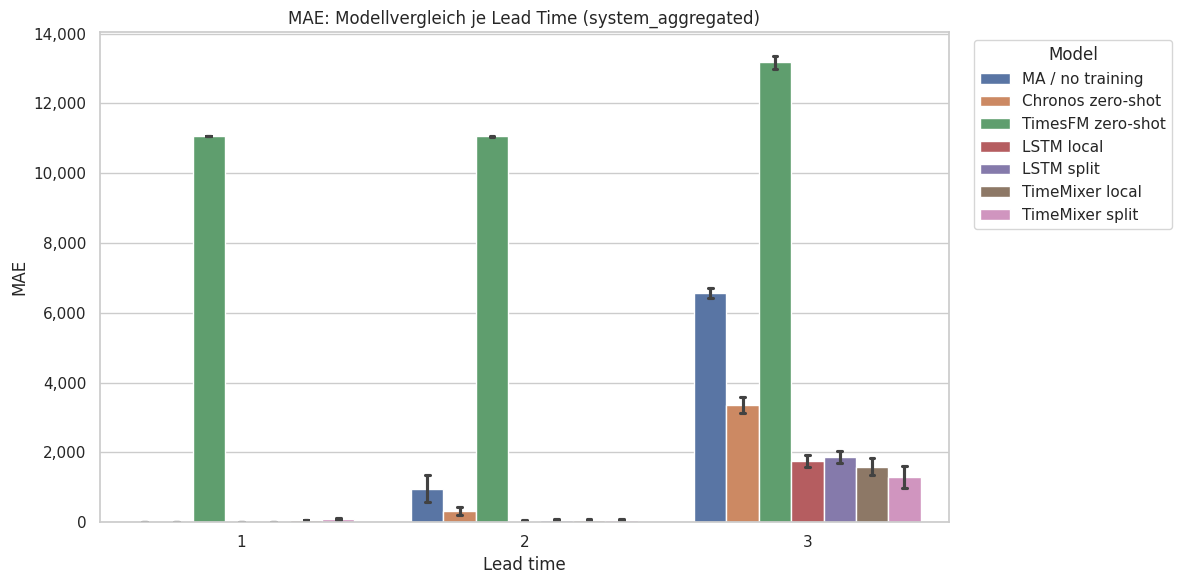

Saved: /home/jupyter-dom30542/designingeffectivecollaborativelearningsystems/Results/Evaluation_Leadtime/MAE_system_aggregated_box_by_leadtime.png


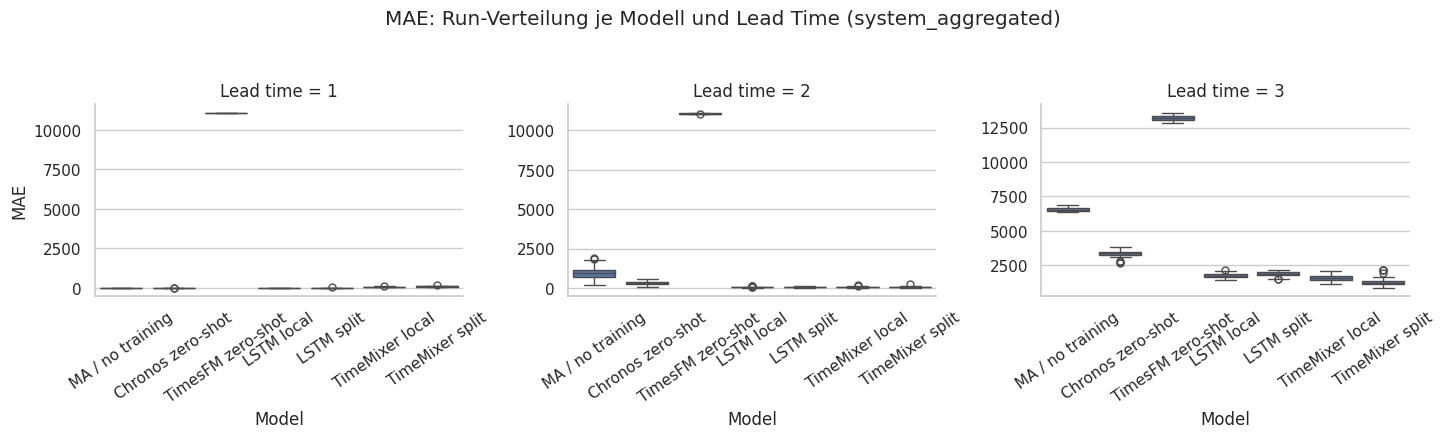

Saved: /home/jupyter-dom30542/designingeffectivecollaborativelearningsystems/Results/Evaluation_Leadtime/MSE_system_aggregated_leadtime_overview.png


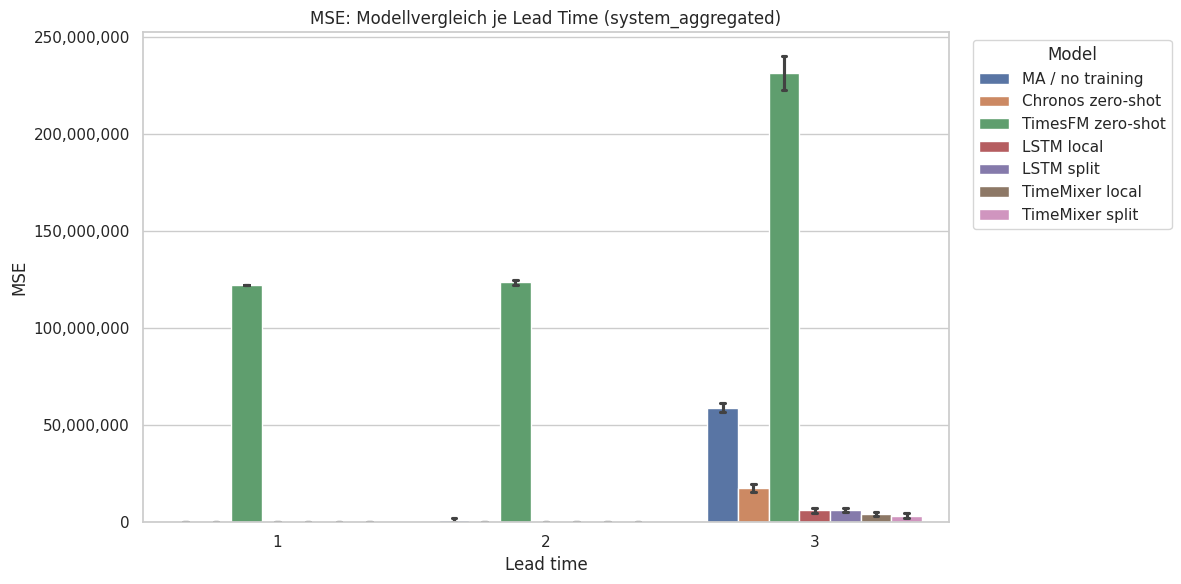

Saved: /home/jupyter-dom30542/designingeffectivecollaborativelearningsystems/Results/Evaluation_Leadtime/MSE_system_aggregated_box_by_leadtime.png


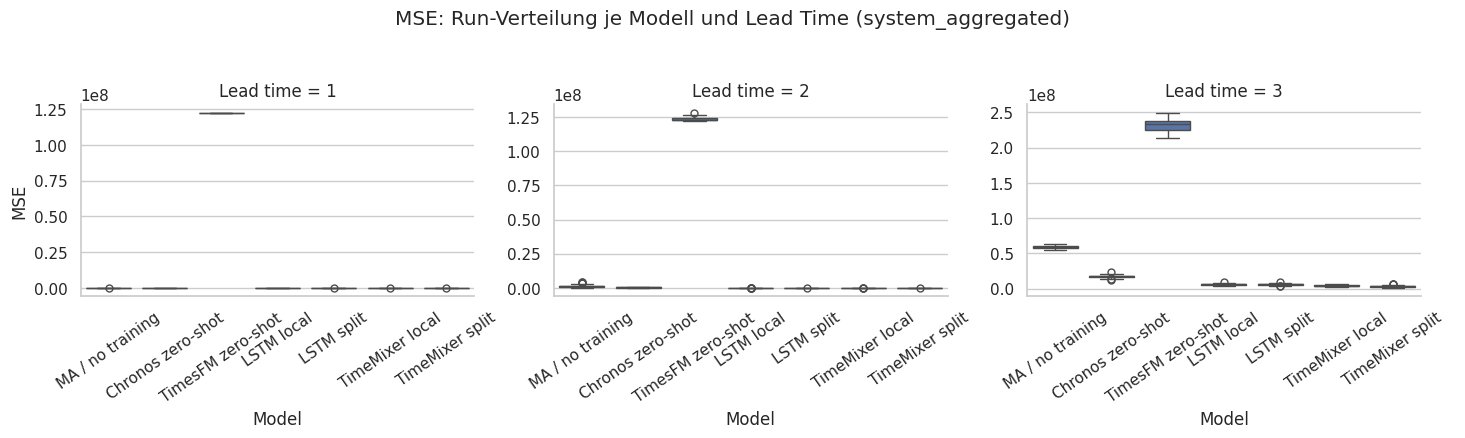

In [13]:
# Standardplots erzeugen
for metric in ["MAE", "MSE"]:
    if metric in set(run_metrics["metric"]):
        plot_leadtime_overview(metric=metric, level="system_aggregated")
        plt.show()

        plot_models_within_each_leadtime(metric=metric, level="system_aggregated")
        plt.show()

Saved: /home/jupyter-dom30542/designingeffectivecollaborativelearningsystems/Results/Evaluation_Leadtime/MAE_system_aggregated_scenarios_leadtime_1.png


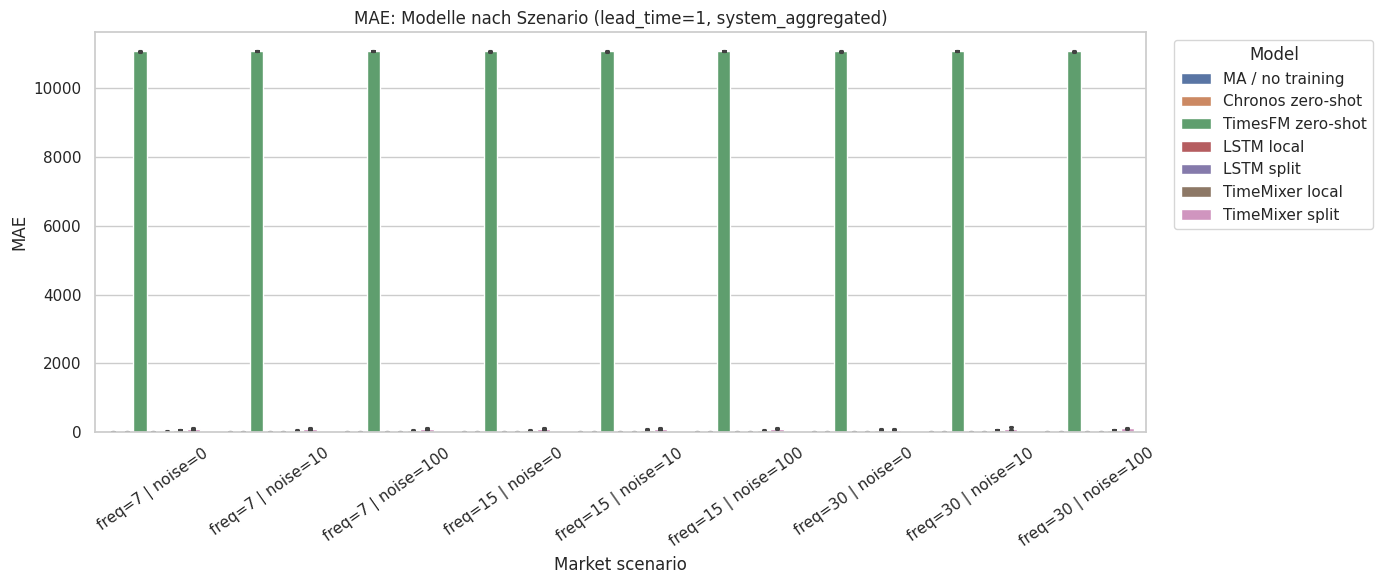

Saved: /home/jupyter-dom30542/designingeffectivecollaborativelearningsystems/Results/Evaluation_Leadtime/MAE_system_aggregated_scenarios_leadtime_2.png


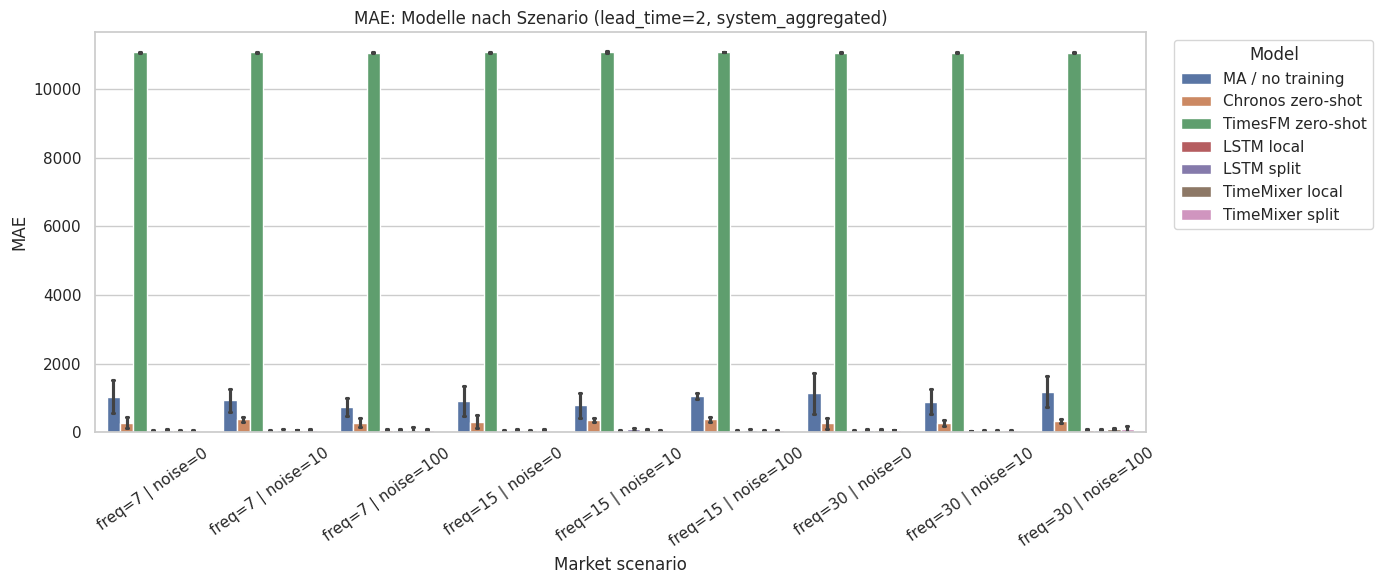

Saved: /home/jupyter-dom30542/designingeffectivecollaborativelearningsystems/Results/Evaluation_Leadtime/MAE_system_aggregated_scenarios_leadtime_3.png


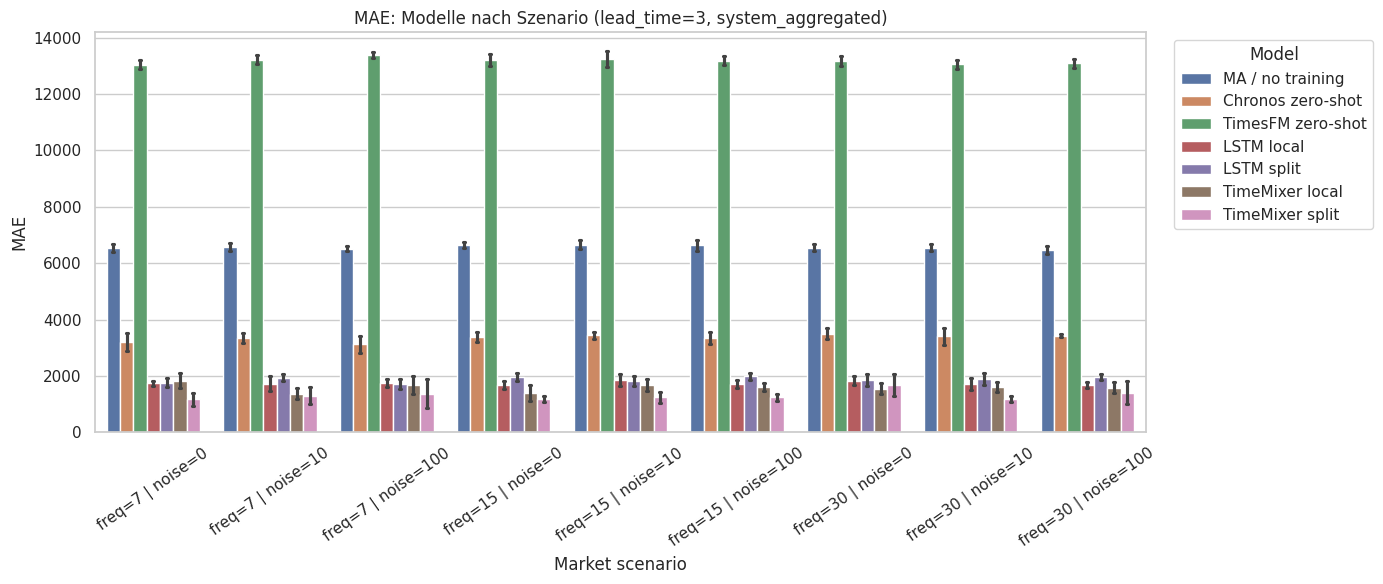

Saved: /home/jupyter-dom30542/designingeffectivecollaborativelearningsystems/Results/Evaluation_Leadtime/MSE_system_aggregated_scenarios_leadtime_1.png


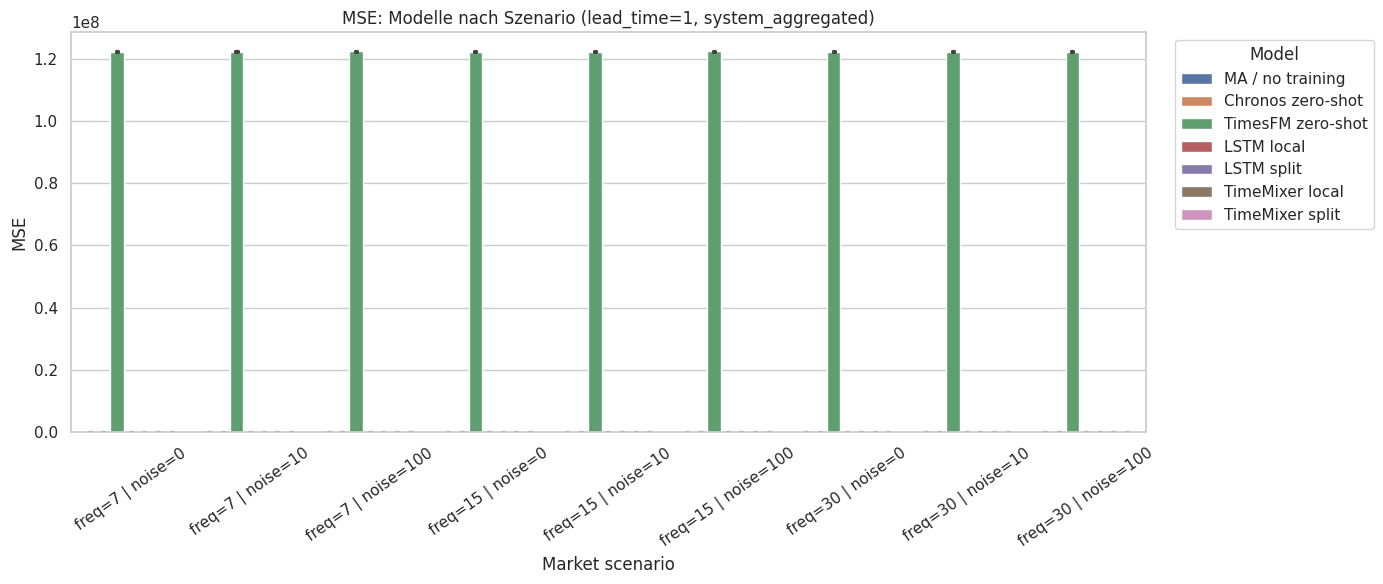

Saved: /home/jupyter-dom30542/designingeffectivecollaborativelearningsystems/Results/Evaluation_Leadtime/MSE_system_aggregated_scenarios_leadtime_2.png


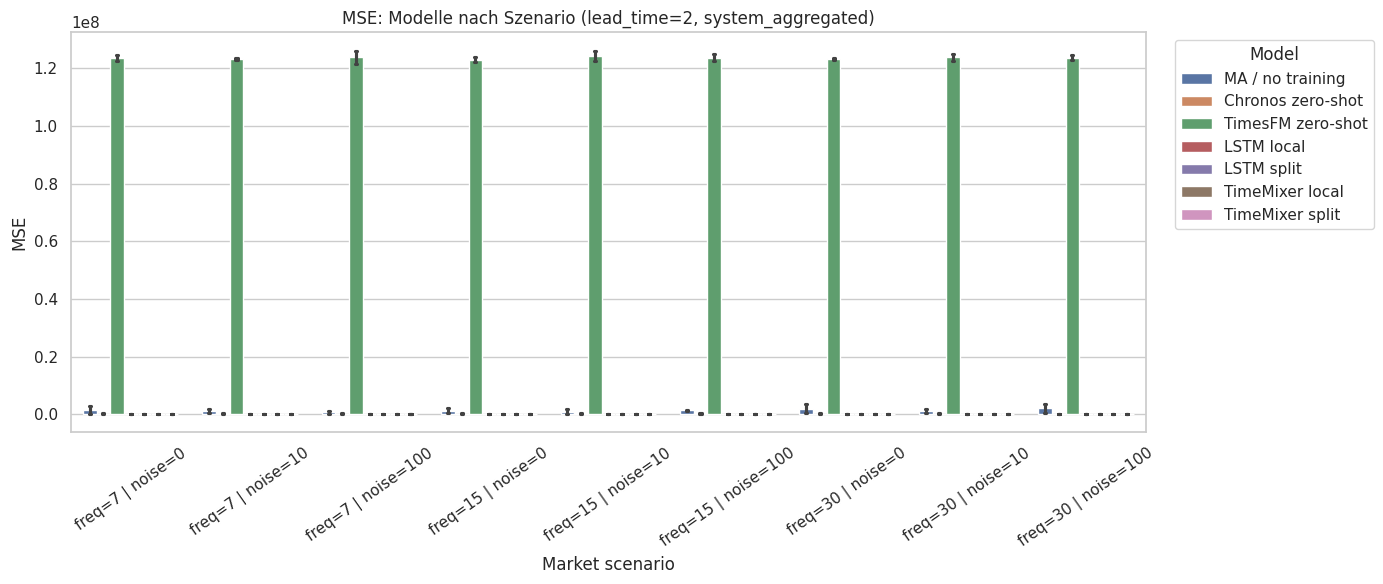

Saved: /home/jupyter-dom30542/designingeffectivecollaborativelearningsystems/Results/Evaluation_Leadtime/MSE_system_aggregated_scenarios_leadtime_3.png


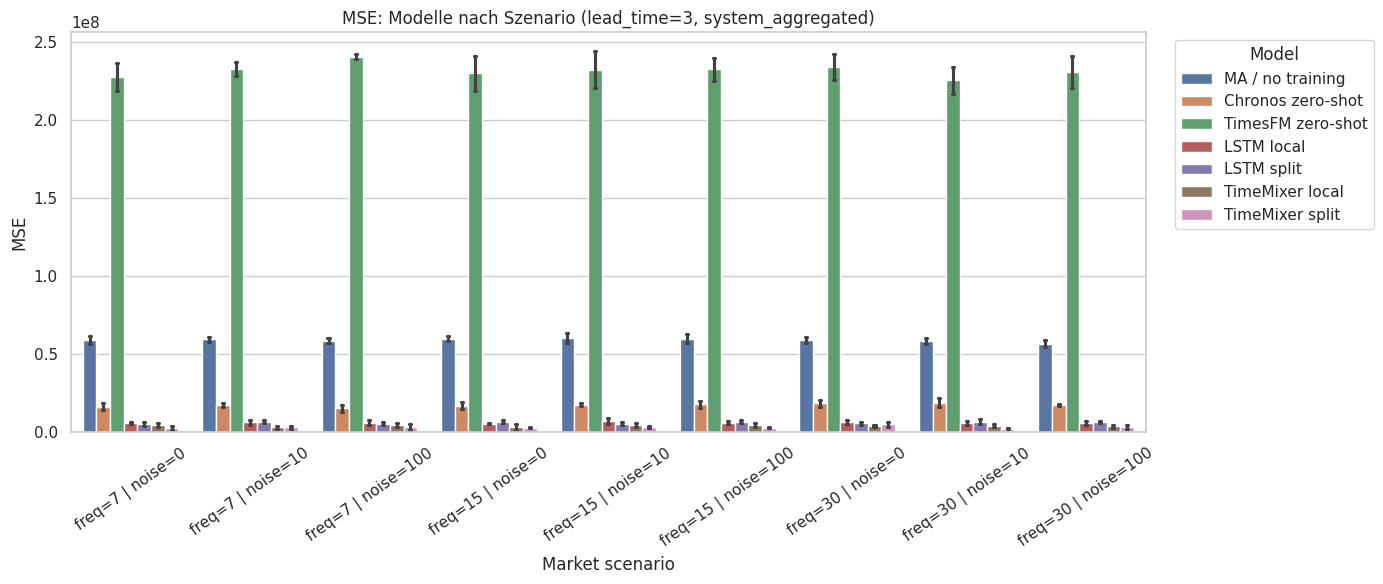

In [14]:
# Optional: Szenarioplot für jede Lead Time
for metric in ["MAE", "MSE"]:
    if metric not in set(run_metrics["metric"]):
        continue

    for lead in sorted(run_metrics["lead_time"].dropna().astype(str).unique()):
        plot_scenarios_for_leadtime(metric=metric, lead_time=lead, level="system_aggregated")
        plt.show()

## 7) Statistik: Modellpaare je Lead Time vergleichen

Hinweis: Das Notebook nutzt standardmäßig **Welch t-tests** und **Mann-Whitney-U-tests** zwischen Modellgruppen.
Das ist absichtlich unabhängig statt gepaart, weil in deinem Scheduler der Seed aus `experiment_id` und `run_id` gebildet wird. Dadurch ist `run_0` bei Modell A nicht zwingend derselbe Seed wie `run_0` bei Modell B.

In [15]:
def benjamini_hochberg(p_values):
    p_values = np.asarray(p_values, dtype=float)
    adjusted = np.full_like(p_values, np.nan, dtype=float)

    valid = np.isfinite(p_values)
    if valid.sum() == 0:
        return adjusted

    p = p_values[valid]
    order = np.argsort(p)
    ranked = p[order]
    m = len(ranked)

    adj_ranked = ranked * m / (np.arange(1, m + 1))
    adj_ranked = np.minimum.accumulate(adj_ranked[::-1])[::-1]
    adj_ranked = np.clip(adj_ranked, 0, 1)

    out_valid = np.empty_like(p)
    out_valid[order] = adj_ranked
    adjusted[valid] = out_valid
    return adjusted


def pairwise_model_tests(
    df,
    metric="MAE",
    level="system_aggregated",
    group_cols=("lead_time",),
    include_scenario=False,
):
    if include_scenario:
        group_cols = tuple(list(group_cols) + ["seasonality_frequency", "noise_level"])

    d = df[(df["metric"].eq(metric)) & (df["level"].eq(level))].copy()
    d = d[np.isfinite(d["value"])]

    rows = []

    for group_key, g in d.groupby(list(group_cols), dropna=False):
        if not isinstance(group_key, tuple):
            group_key = (group_key,)

        models = sorted(g["model_label"].dropna().unique())

        for model_a, model_b in combinations(models, 2):
            a = g[g["model_label"].eq(model_a)]["value"].dropna().to_numpy()
            b = g[g["model_label"].eq(model_b)]["value"].dropna().to_numpy()

            if len(a) < 2 or len(b) < 2:
                t_stat, t_p = np.nan, np.nan
            else:
                t_stat, t_p = stats.ttest_ind(a, b, equal_var=False, nan_policy="omit")

            if len(a) < 1 or len(b) < 1:
                u_stat, u_p = np.nan, np.nan
            else:
                try:
                    u_stat, u_p = stats.mannwhitneyu(a, b, alternative="two-sided")
                except Exception:
                    u_stat, u_p = np.nan, np.nan

            row = dict(zip(group_cols, group_key))
            row.update({
                "metric": metric,
                "level": level,
                "model_a": model_a,
                "model_b": model_b,
                "n_a": len(a),
                "n_b": len(b),
                "mean_a": np.nanmean(a) if len(a) else np.nan,
                "mean_b": np.nanmean(b) if len(b) else np.nan,
                "mean_diff_a_minus_b": (np.nanmean(a) - np.nanmean(b)) if len(a) and len(b) else np.nan,
                "welch_t": t_stat,
                "welch_p": t_p,
                "mannwhitney_u": u_stat,
                "mannwhitney_p": u_p,
            })
            rows.append(row)

    result = pd.DataFrame(rows)

    if not result.empty:
        result["welch_p_adj_bh"] = benjamini_hochberg(result["welch_p"].to_numpy())
        result["mannwhitney_p_adj_bh"] = benjamini_hochberg(result["mannwhitney_p"].to_numpy())

    return result


tests_by_leadtime = []
for metric in ["MAE", "MSE", "R2"]:
    if metric in set(run_metrics["metric"]):
        tests_by_leadtime.append(
            pairwise_model_tests(
                run_metrics,
                metric=metric,
                level="system_aggregated",
                group_cols=("lead_time",),
                include_scenario=False,
            )
        )

tests_by_leadtime = pd.concat(tests_by_leadtime, ignore_index=True) if tests_by_leadtime else pd.DataFrame()
display(tests_by_leadtime.head(50))

,lead_time,metric,level,model_a,model_b,n_a,n_b,mean_a,mean_b,mean_diff_a_minus_b,welch_t,welch_p,mannwhitney_u,mannwhitney_p,welch_p_adj_bh,mannwhitney_p_adj_bh
0,1,MAE,system_aggregated,Chronos zero-shot,LSTM local,45,45,13.282540,12.954061,0.328478,1.151009,2.528478e-01,1126.0,3.618221e-01,2.654902e-01,3.736851e-01
1,1,MAE,system_aggregated,Chronos zero-shot,LSTM split,45,45,13.282540,14.625881,-1.343342,-2.195850,3.235275e-02,661.0,4.618054e-03,3.454616e-02,5.016162e-03
2,1,MAE,system_aggregated,Chronos zero-shot,MA / no training,45,45,13.282540,17.118367,-3.835828,-13.846900,9.351923e-24,47.0,6.828669e-15,1.592354e-23,1.000479e-14
3,1,MAE,system_aggregated,Chronos zero-shot,TimeMixer local,45,45,13.282540,62.438800,-49.156260,-27.026194,1.653520e-29,0.0,3.168386e-16,3.472392e-29,5.403842e-16
4,1,MAE,system_aggregated,Chronos zero-shot,TimeMixer split,45,45,13.282540,100.362693,-87.080154,-21.931835,2.130171e-25,0.0,3.168386e-16,3.834307e-25,5.403842e-16
5,1,MAE,system_aggregated,Chronos zero-shot,TimesFM zero-shot,45,45,13.282540,11056.560998,-11043.278458,-37527.932943,2.701798e-318,0.0,3.162215e-16,1.470280e-316,5.403842e-16
6,1,MAE,system_aggregated,LSTM local,LSTM split,45,45,12.954061,14.625881,-1.671820,-2.738792,8.319387e-03,569.0,3.503922e-04,9.195112e-03,4.013583e-04
7,1,MAE,system_aggregated,LSTM local,MA / no training,45,45,12.954061,17.118367,-4.164306,-15.195890,2.723220e-26,12.0,7.037507e-16,5.361340e-26,1.108407e-15
8,1,MAE,system_aggregated,LSTM local,TimeMixer local,45,45,12.954061,62.438800,-49.484739,-27.213536,1.286072e-29,0.0,3.173685e-16,2.793880e-29,5.403842e-16
9,1,MAE,system_aggregated,LSTM local,TimeMixer split,45,45,12.954061,100.362693,-87.408632,-22.015710,1.837679e-25,0.0,3.173685e-16,3.405111e-25,5.403842e-16


In [16]:
# Optional strenger: Modellvergleich je Lead Time UND je freq/noise-Szenario
tests_by_leadtime_scenario = []
for metric in ["MAE", "MSE", "R2"]:
    if metric in set(run_metrics["metric"]):
        tests_by_leadtime_scenario.append(
            pairwise_model_tests(
                run_metrics,
                metric=metric,
                level="system_aggregated",
                group_cols=("lead_time",),
                include_scenario=True,
            )
        )

tests_by_leadtime_scenario = (
    pd.concat(tests_by_leadtime_scenario, ignore_index=True)
    if tests_by_leadtime_scenario
    else pd.DataFrame()
)

display(tests_by_leadtime_scenario.head(50))

if SAVE_TABLES:
    stats_path = OUTPUT_DIR / "leadtime_model_pairwise_tests.xlsx"
    with pd.ExcelWriter(stats_path, engine="openpyxl") as writer:
        tests_by_leadtime.to_excel(writer, sheet_name="by_leadtime", index=False)
        tests_by_leadtime_scenario.to_excel(writer, sheet_name="by_leadtime_scenario", index=False)
    print(f"Saved: {stats_path}")

,lead_time,seasonality_frequency,noise_level,metric,level,model_a,model_b,n_a,n_b,mean_a,mean_b,mean_diff_a_minus_b,welch_t,welch_p,mannwhitney_u,mannwhitney_p,welch_p_adj_bh,mannwhitney_p_adj_bh
0,1,7,0,MAE,system_aggregated,Chronos zero-shot,LSTM local,5,5,12.551020,13.043663,-0.492642,-0.404501,6.966412e-01,10.0,0.690476,7.287741e-01,0.726345
1,1,7,0,MAE,system_aggregated,Chronos zero-shot,LSTM split,5,5,12.551020,18.447671,-5.896651,-1.170968,3.027136e-01,8.0,0.420635,3.419096e-01,0.464008
2,1,7,0,MAE,system_aggregated,Chronos zero-shot,MA / no training,5,5,12.551020,16.457143,-3.906122,-3.543740,9.542917e-03,1.0,0.015873,1.376803e-02,0.020737
3,1,7,0,MAE,system_aggregated,Chronos zero-shot,TimeMixer local,5,5,12.551020,68.091849,-55.540828,-15.101970,4.771535e-05,0.0,0.007937,1.065142e-04,0.010817
4,1,7,0,MAE,system_aggregated,Chronos zero-shot,TimeMixer split,5,5,12.551020,104.408376,-91.857355,-8.639877,9.229027e-04,0.0,0.007937,1.655968e-03,0.010817
5,1,7,0,MAE,system_aggregated,Chronos zero-shot,TimesFM zero-shot,5,5,12.551020,11056.110204,-11043.559184,-10037.612807,4.736596e-26,0.0,0.007937,9.591607e-25,0.010817
6,1,7,0,MAE,system_aggregated,LSTM local,LSTM split,5,5,13.043663,18.447671,-5.404008,-1.077501,3.391050e-01,9.0,0.547619,3.799852e-01,0.593690
7,1,7,0,MAE,system_aggregated,LSTM local,MA / no training,5,5,13.043663,16.457143,-3.413480,-3.396458,1.041784e-02,1.0,0.015873,1.473046e-02,0.020737
8,1,7,0,MAE,system_aggregated,LSTM local,TimeMixer local,5,5,13.043663,68.091849,-55.048186,-15.082713,5.875682e-05,0.0,0.007937,1.301372e-04,0.010817
9,1,7,0,MAE,system_aggregated,LSTM local,TimeMixer split,5,5,13.043663,104.408376,-91.364713,-8.601340,9.543893e-04,0.0,0.007937,1.707062e-03,0.010817


Saved: /home/jupyter-dom30542/designingeffectivecollaborativelearningsystems/Results/Evaluation_Leadtime/leadtime_model_pairwise_tests.xlsx


## 8) Agent-Level-Auswertung

Saved: /home/jupyter-dom30542/designingeffectivecollaborativelearningsystems/Results/Evaluation_Leadtime/MAE_agent_level_leadtime_all.png


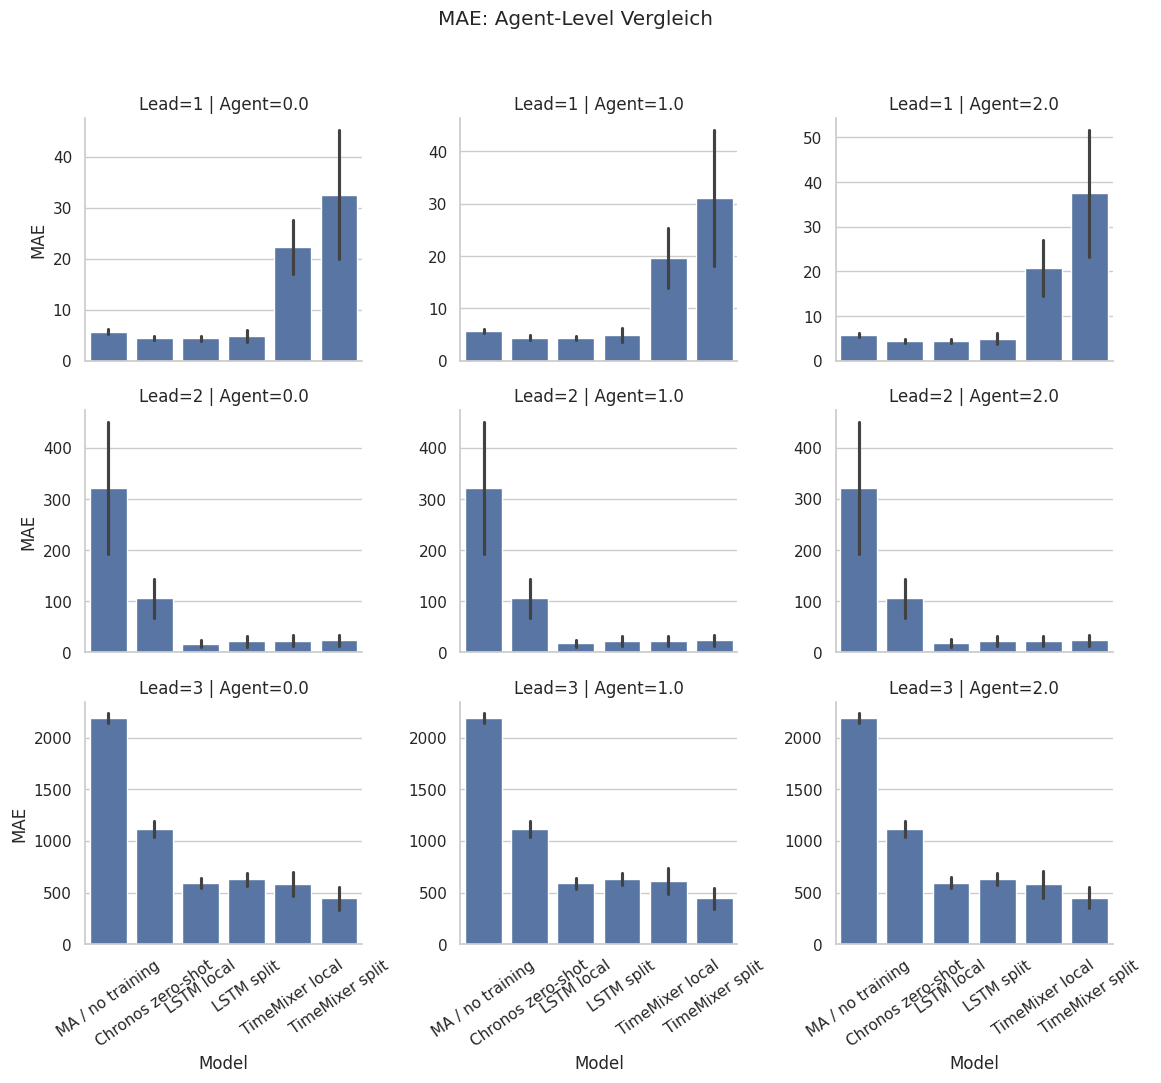

In [17]:
def plot_agent_level(metric="MAE", lead_time=None, save=True):
    d = run_metrics[
        (run_metrics["metric"].eq(metric))
        & (run_metrics["level"].eq("agent"))
    ].copy()
    d = filter_plot_data(d)
    d = d[np.isfinite(d["value"])]

    if lead_time is not None:
        d = d[d["lead_time"].astype(str).eq(str(lead_time))]

    if d.empty:
        print(f"No agent-level data for metric={metric}, lead_time={lead_time} after plot filter")
        return None

    order = _ordered_labels(d["model_label"].dropna().unique())

    g = sns.catplot(
        data=d,
        x="model_label",
        y="value",
        col="agent_id",
        row="lead_time" if lead_time is None else None,
        kind="bar",
        order=order,
        errorbar="sd",
        height=3.5,
        aspect=1.1,
        sharey=False,
    )

    g.set_axis_labels("Model", metric)
    g.set_titles("Lead={row_name} | Agent={col_name}" if lead_time is None else "Agent={col_name}")

    for ax in g.axes.flat:
        ax.tick_params(axis="x", rotation=35)

    g.fig.suptitle(f"{metric}: Agent-Level Vergleich", y=1.03)
    plt.tight_layout()

    if save and SAVE_FIGURES:
        lead_name = "all" if lead_time is None else str(lead_time).replace("/", "-")
        suffix = ""
        excluded = _normalized_plot_exclusions()
        if excluded:
            suffix = "_plot_filtered"
        path = OUTPUT_DIR / f"{metric}_agent_level_leadtime_{lead_name}{suffix}.png"
        g.savefig(path, dpi=200, bbox_inches="tight")
        print(f"Saved: {path}")

    return g


# Beispiel:
if "MAE" in set(run_metrics["metric"]):
    plot_agent_level(metric="MAE", lead_time=None)
    plt.show()


## 9) Optional: BEW_measures.csv zusätzlich laden

In [18]:
def load_bew_measures(experiments_df):
    rows = []
    for _, exp in experiments_df.iterrows():
        exp_path = Path(exp["experiment_path"])
        bew_path = exp_path / "BEW_measures.csv"
        if not bew_path.exists():
            continue

        try:
            df = pd.read_csv(bew_path)
        except Exception as exc:
            warnings.warn(f"Could not load {bew_path}: {exc}")
            continue

        # Config-Metadaten anhängen
        for col in [
            "experiment_folder", "training_type", "model", "model_label",
            "lead_time", "lead_time_l0", "lead_time_l1",
            "seasonality_frequency", "noise_level",
        ]:
            if col in exp.index:
                df[col] = exp[col]

        df["bew_path"] = str(bew_path)
        rows.append(df)

    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()


bew_measures = load_bew_measures(experiments_df)
print(f"BEW rows: {len(bew_measures)}")
display(bew_measures.head())

if SAVE_TABLES and not bew_measures.empty:
    bew_path = OUTPUT_DIR / "bew_measures_with_config_metadata.xlsx"
    bew_measures.to_excel(bew_path, index=False)
    print(f"Saved: {bew_path}")

BEW rows: 0


""


## 10) Was du typischerweise berichtest

- `summary_system_agg`: Mittelwert und Standardabweichung über Seeds/Runs je Modell, Lead Time, Frequency und Noise.
- `best_by_leadtime`: bestes Modell je Lead Time und Metrik.
- `pivot_system_mean`: breite Tabelle für direkten Modellvergleich.
- `*_leadtime_overview.png`: Übersicht über Lead Times.
- `*_box_by_leadtime.png`: Run-Verteilung pro Modell und Lead Time.
- `leadtime_model_pairwise_tests.xlsx`: Welch-Tests und Mann-Whitney-U-Tests für Modellpaare.

Für die meisten Ergebnisplots ist `level="system_aggregated"` sinnvoll, weil es das gesamte System je Run bewertet.  
`level="system_sum_agents"` entspricht eher der alten Logik, bei der Agentenmetriken summiert wurden.